# 2. Bigrams
In this notebook, I am continuing a similar pipeline to what was shown in the EE (Extension or Expansion) article by working with bigrams. However, I am working with a broader range of target words, and not comparing UK results to that of other countries. I also periodized my data by decades, of which I decided to exclude 1979 (as there was no reason to isolate it in a different decade, nor mash it up with the 80s) and 2021-21 (as Covid was a weird time, for the lack of better words). This helped me keep the decades neat and well-justified. That said, I did experiment around prior to this by defining periods of 2010-2019, 2010-2021, and 2020-2021 separately. I compared their results and saved their files, so if you'd like to see more of those results let me know! Or, I might post it on my Tumblr.

What I found from experimenting with including / excluding the Covid years is that on matters of democracy and fascism, the top few bigrams / most frequent bigrams were _generally not_ affected by the inclusion or exclusion of 2020-2021. However, it did skew things a lot for "crisis" related terms -- less so for overall 2010-2021 crisis terms, but in isolation, 2020-2021 discourse was dominated with Covid-related crises. Even so, as parliamentary debates, other governmental operations, and institutions like healthcare had to change operation formats drastically due to proactive measures taken at the time to stop the spread, I thought that it wouldn't be so fair to include 2020-2021 anyways. This also makes the decade divisions cleaner and easier to justify.

In [1]:
from collections import Counter
import pandas as pd
import glob
import ast
import matplotlib.pyplot as plt
import os

words_to_find = ["democratic", "democracy", "undemocratic", "fascist", "fascism", "crisis", "critical"]

In [2]:
periods = {"1980_1989": (1979, 1989), "1990_1999": (1990, 1999), "2000_2009": (2000, 2009), "2010_2019": (2010, 2019)}
#just wanna see if it's worth including 2021 into the prior decade... it's just one year after all, but we also know that Covid took a toll since 2020. Whether it affects the lexical and semantic parts of politics... we'll see...
#ok i decided to keep just these years, makes decades easier too

In [3]:
input_files = sorted(glob.glob("/Users/inqfinity/mip/hansard_1979-2021/processed_csvs/*_processed.csv"))

output_folder = "/Users/inqfinity/mip/newdecades_bigram_outputs"
os.makedirs(output_folder, exist_ok=True)

Below, we find the top bigrams for each decade and save them into `.csv` files.

In [4]:
for target_word in words_to_find:

    for period_name, (start_year, end_year) in periods.items():

        print(f"\nProcessing: {target_word} | {period_name}")

        bigram_counter = Counter()

        for file in input_files:
            year = int(file.split("/")[-1][:4])
            if not (start_year <= year <= end_year): #pick only period
                continue
            df = pd.read_csv(file, low_memory=False)
            df = df[df["speech_class"] == "Speech"]

            for lemmas in df["speech_lemmas_list"].dropna(): #loop thru speeches
                tokens = ast.literal_eval(lemmas)
                for i in range(len(tokens) - 1): #make bigrams
                    word1 = tokens[i]
                    word2 = tokens[i + 1]
                    if target_word in [word1, word2]: #include bigrams where there is a target
                        bigram = f"{word1} {word2}"
                        bigram_counter[bigram] += 1

        top_50 = bigram_counter.most_common(50) #top 50

        results_df = pd.DataFrame(top_50, columns=["bigram", "count"])

        results_df["target_word"] = target_word
        results_df["period"] = period_name

        results_df = results_df[["target_word", "period", "bigram", "count"]] #reorder

        output_path = (f"{output_folder}/" f"{target_word}_{period_name}_top50_bigrams.csv")

        results_df.to_csv(output_path, index=False)

        print(f"Saved: {output_path}")
        print(results_df.head())


Processing: democratic | 1980_1989
Saved: /Users/inqfinity/mip/newdecades_bigram_outputs/democratic_1980_1989_top50_bigrams.csv
  target_word     period              bigram  count
0  democratic  1980_1989   social democratic   1604
1  democratic  1980_1989    democratic party   1364
2  democratic  1980_1989  democratic process    749
3  democratic  1980_1989    democratic right    717
4  democratic  1980_1989  democratic control    416

Processing: democratic | 1990_1999
Saved: /Users/inqfinity/mip/newdecades_bigram_outputs/democratic_1990_1999_top50_bigrams.csv
  target_word     period                     bigram  count
0  democratic  1990_1999         democratic process   1086
1  democratic  1990_1999  democratic accountability    562
2  democratic  1990_1999         democratic deficit    451
3  democratic  1990_1999           democratic right    392
4  democratic  1990_1999           democratic party    385

Processing: democratic | 2000_2009
Saved: /Users/inqfinity/mip/newdecades_b

## Visualizations!

Below, I produced basic bar graphs for the top 50 bigrams per each period. I picked 50 bigrams as that was what was done in EE. I have all the plots saved, but I might comment them out for when I upload to GitHub.

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democratic_1980_1989_top50_bigrams.png


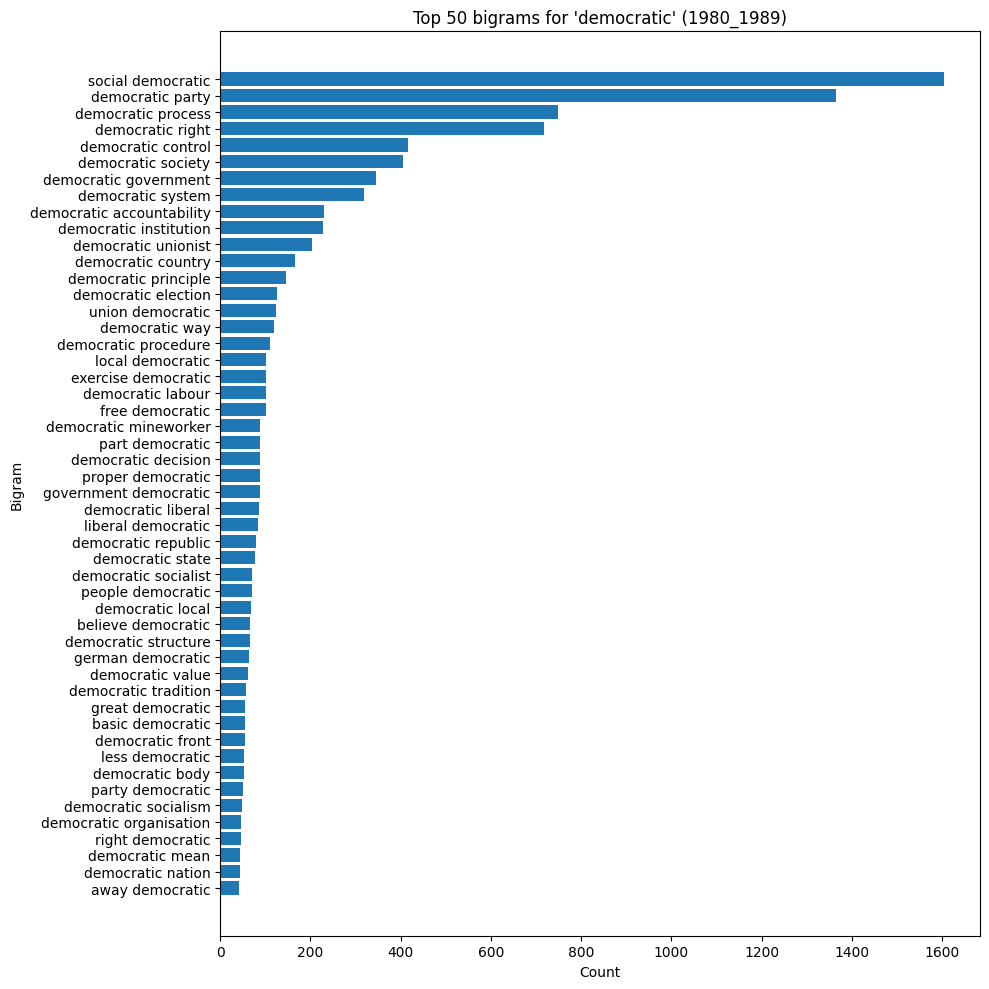

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democratic_1990_1999_top50_bigrams.png


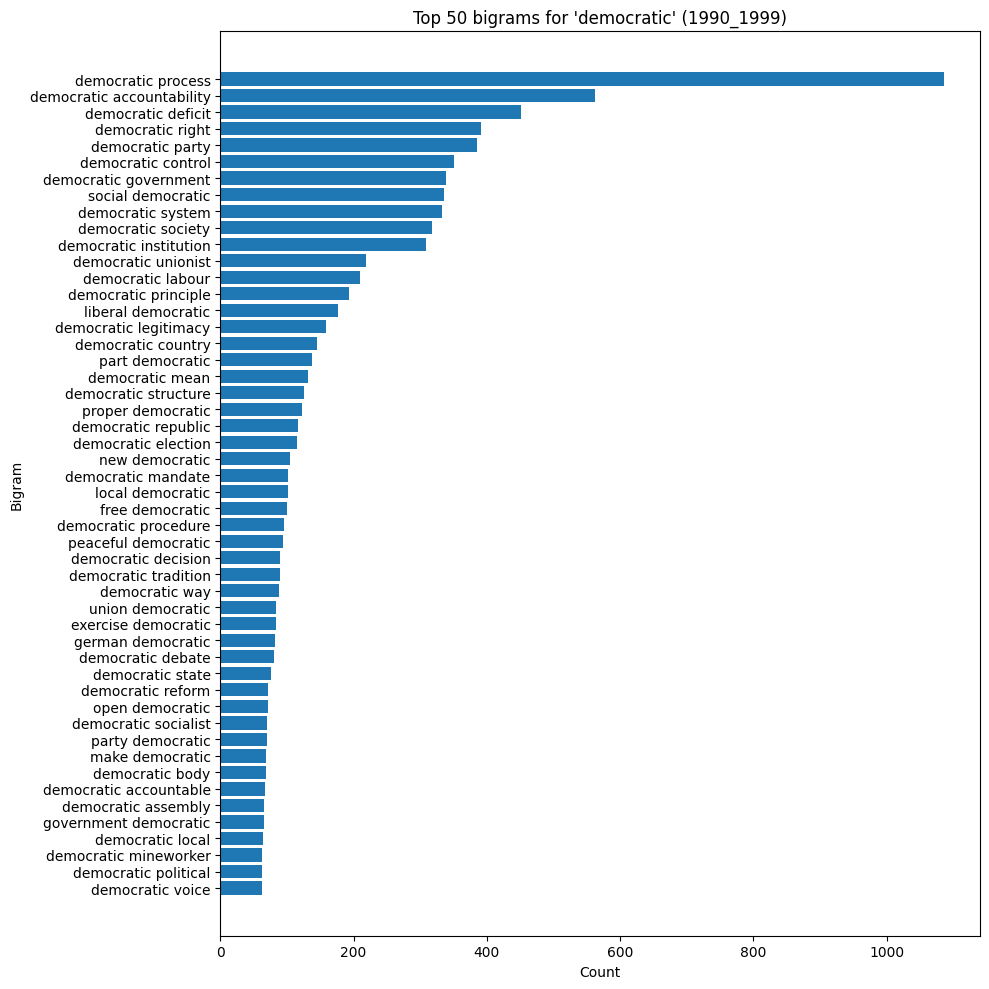

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democratic_2000_2009_top50_bigrams.png


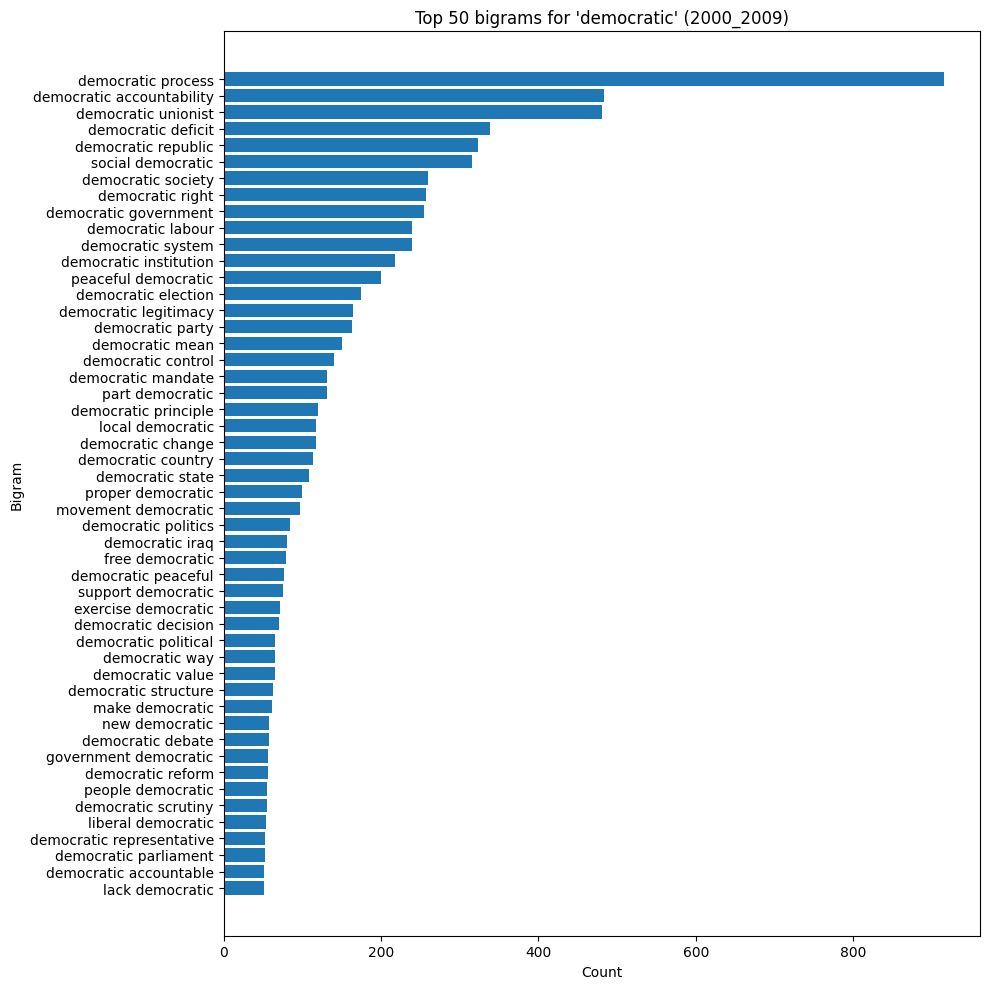

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democratic_2010_2019_top50_bigrams.png


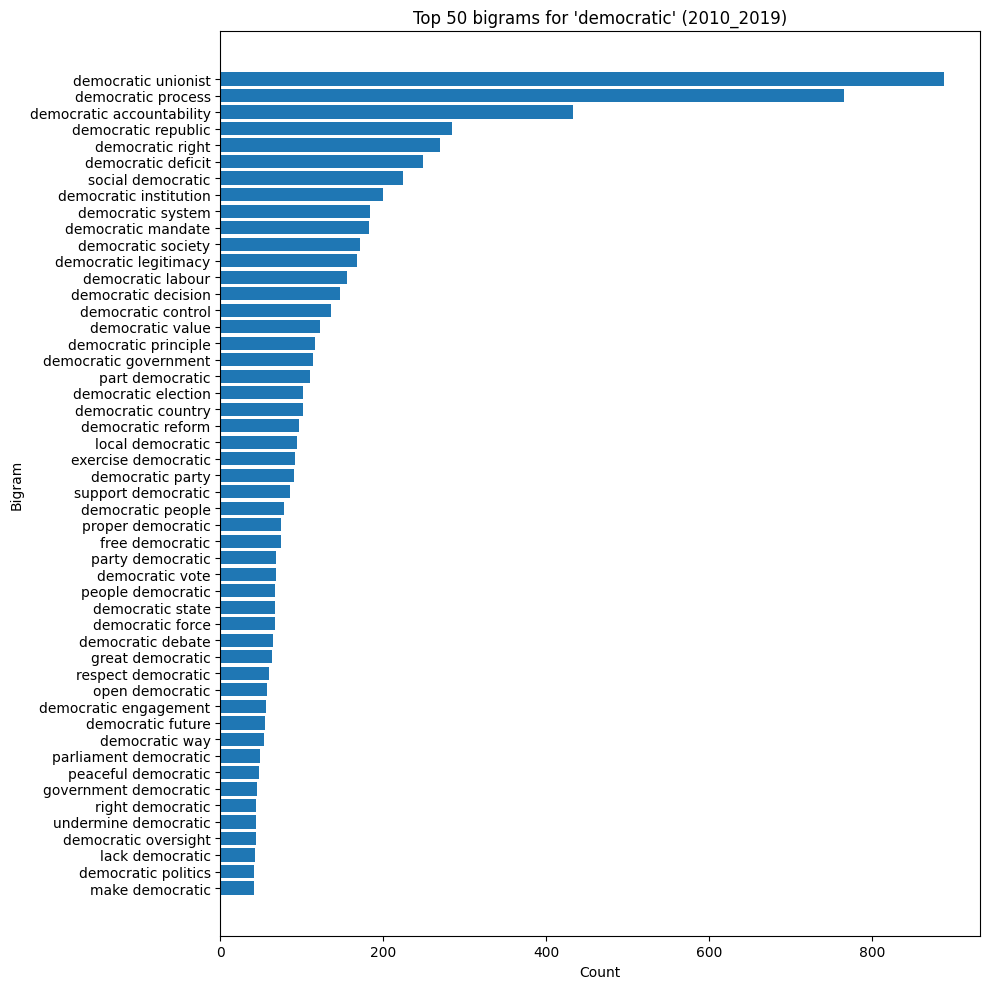

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democracy_1980_1989_top50_bigrams.png


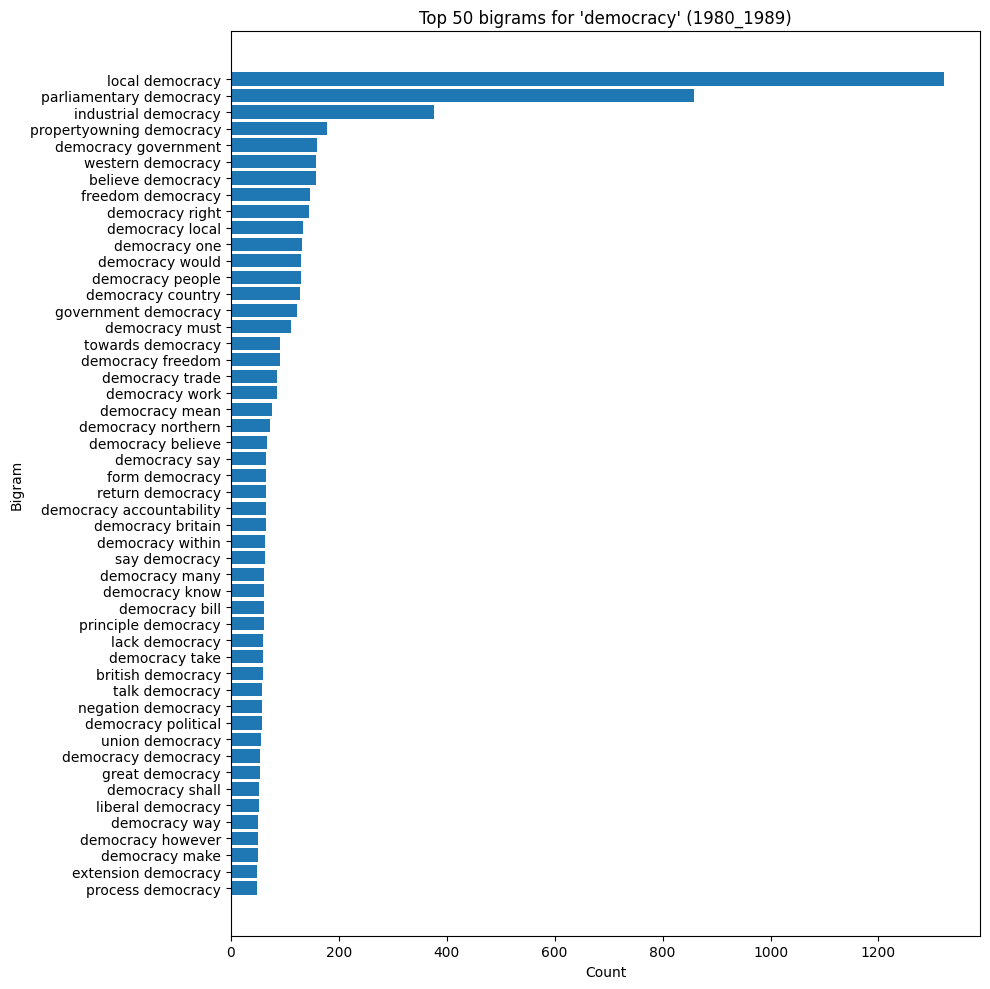

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democracy_1990_1999_top50_bigrams.png


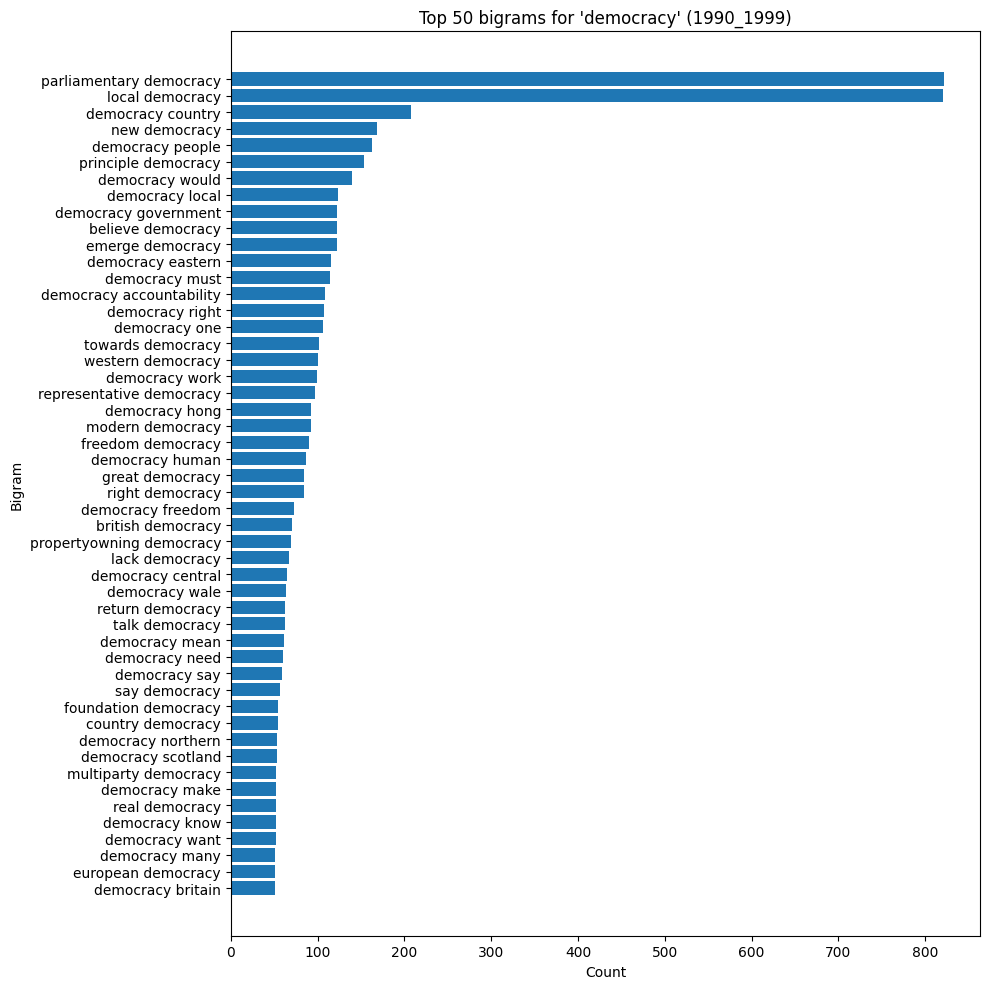

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democracy_2000_2009_top50_bigrams.png


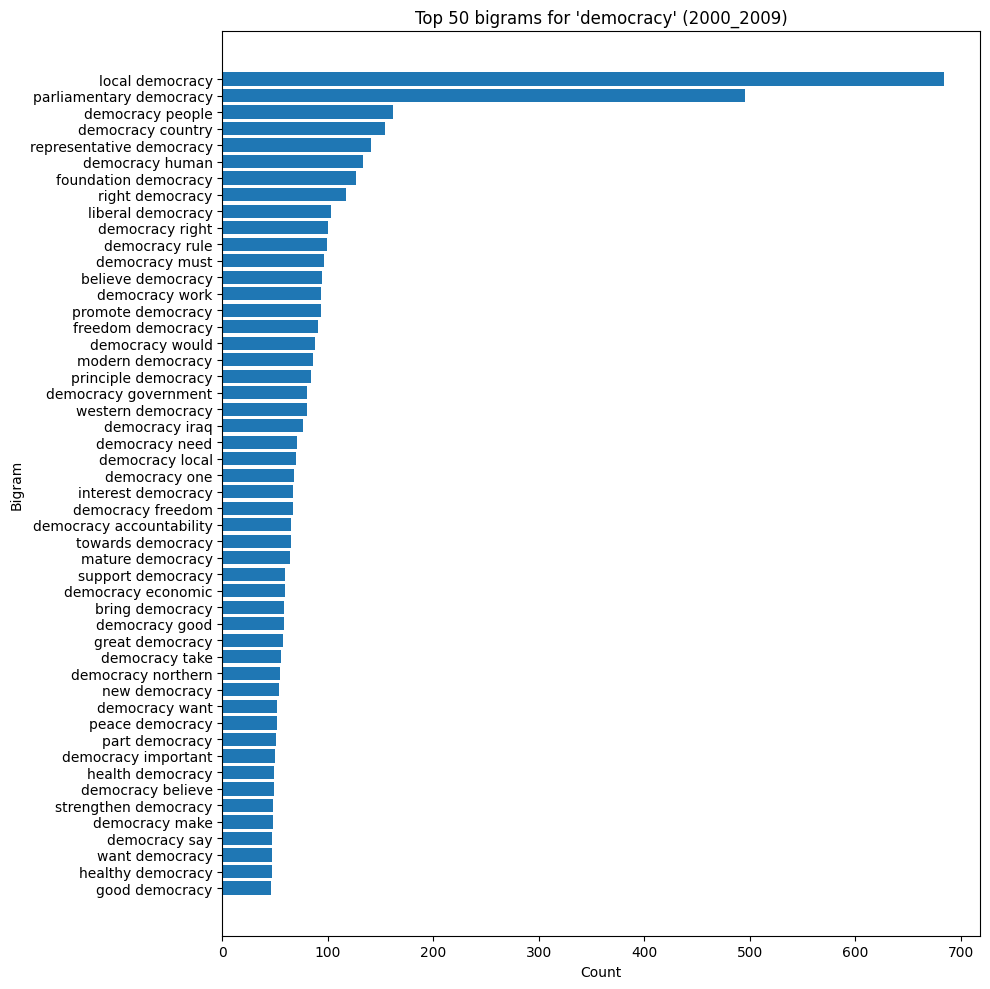

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/democracy_2010_2019_top50_bigrams.png


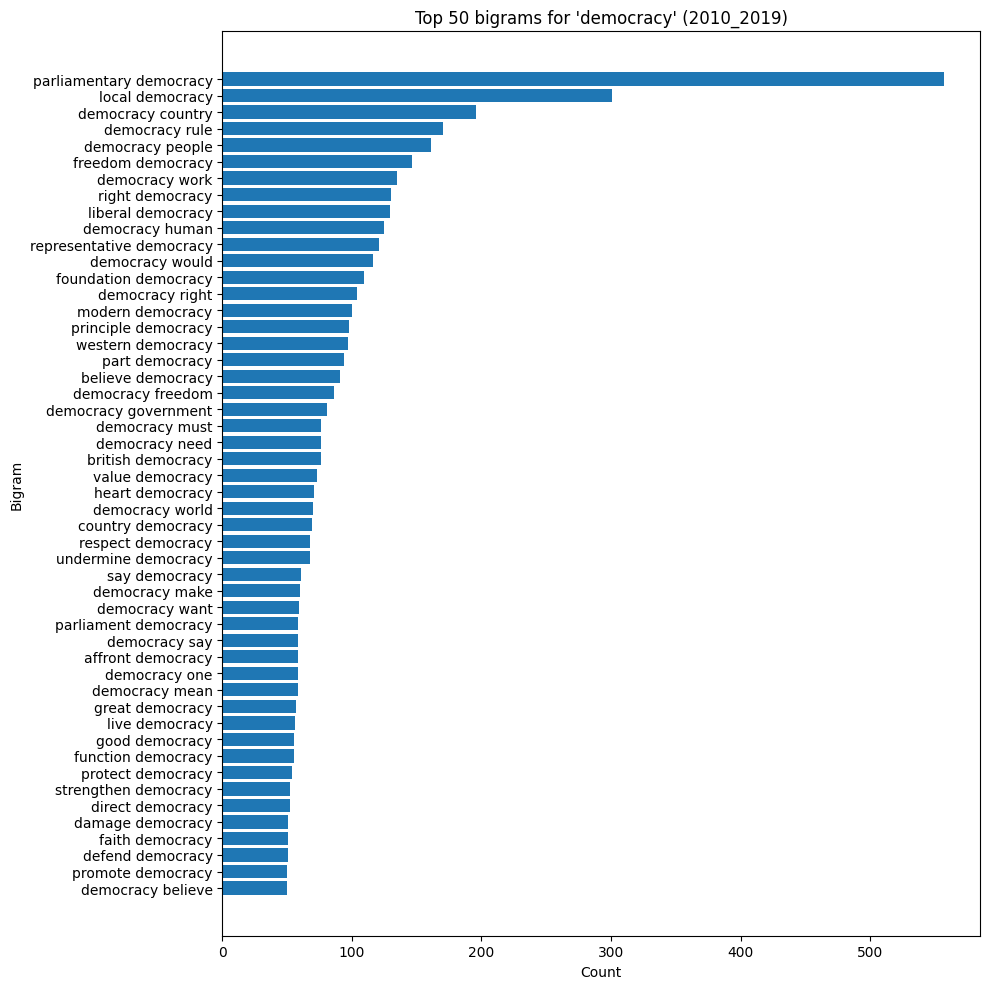

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/undemocratic_1980_1989_top50_bigrams.png


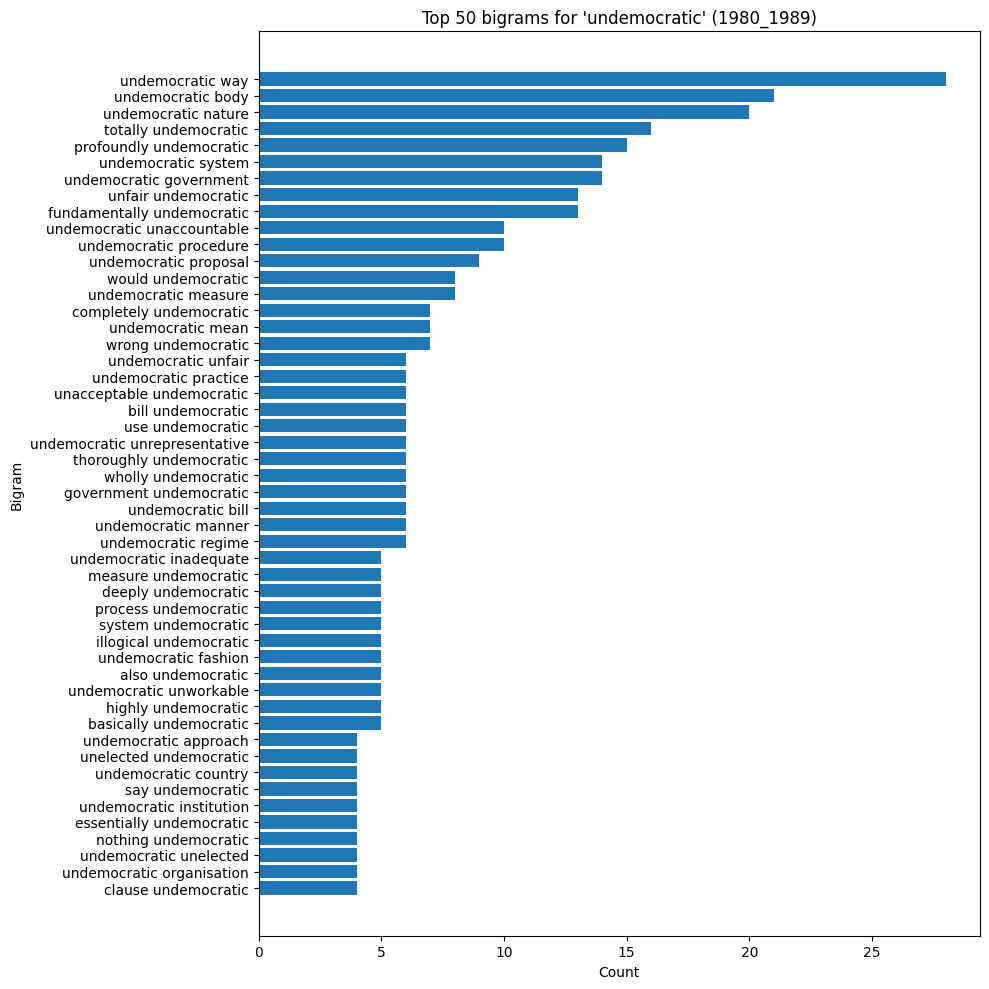

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/undemocratic_1990_1999_top50_bigrams.png


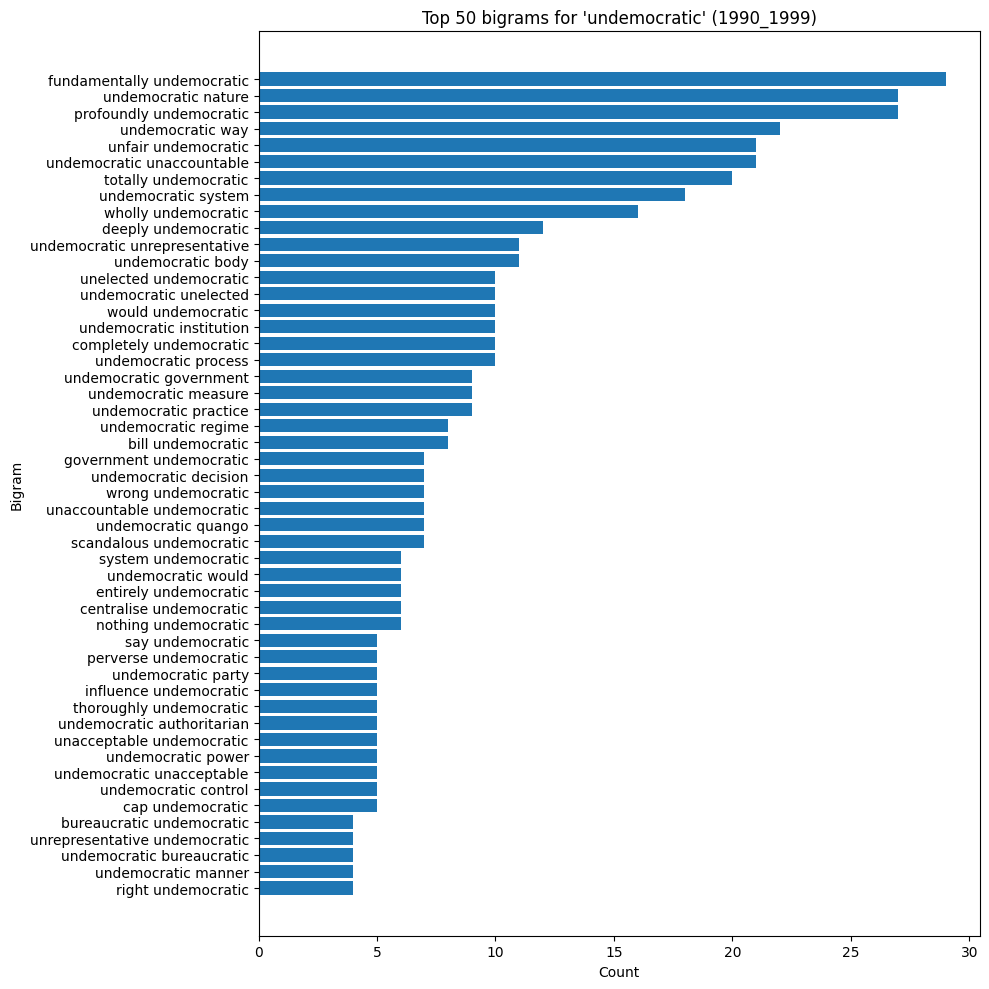

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/undemocratic_2000_2009_top50_bigrams.png


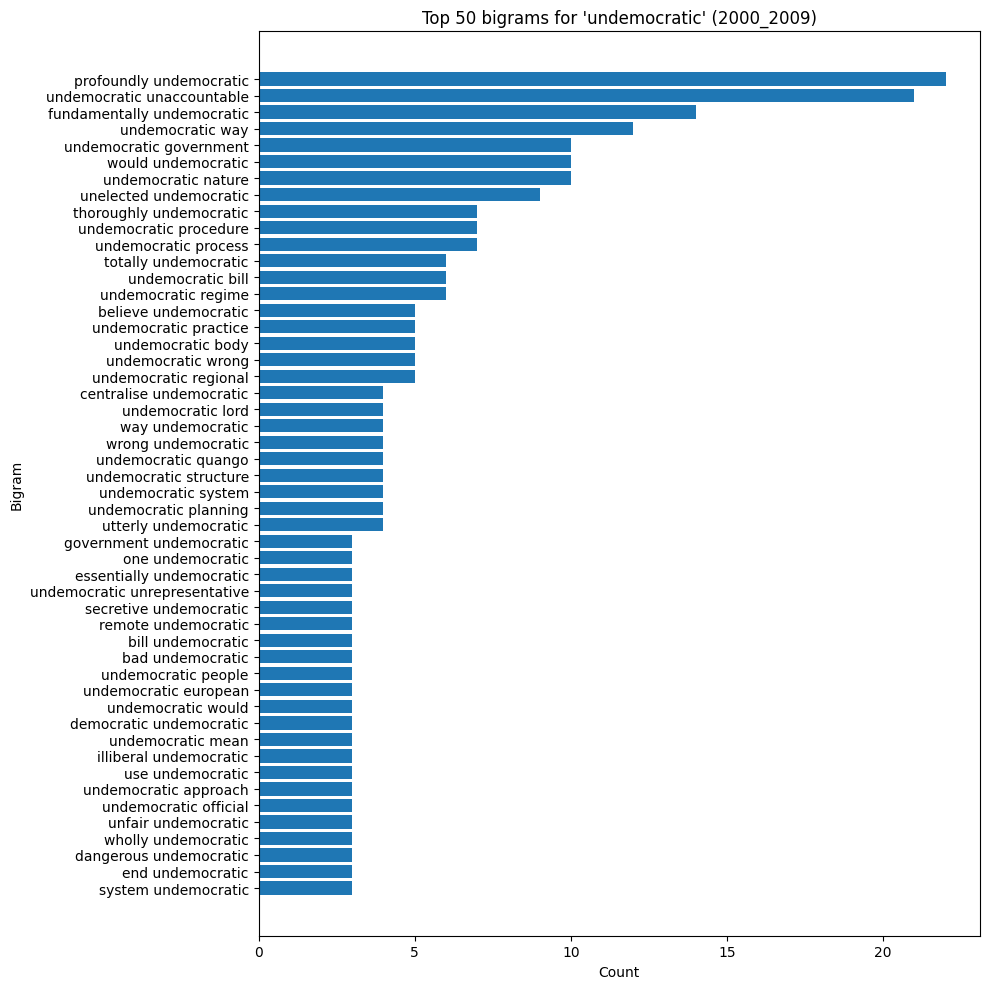

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/undemocratic_2010_2019_top50_bigrams.png


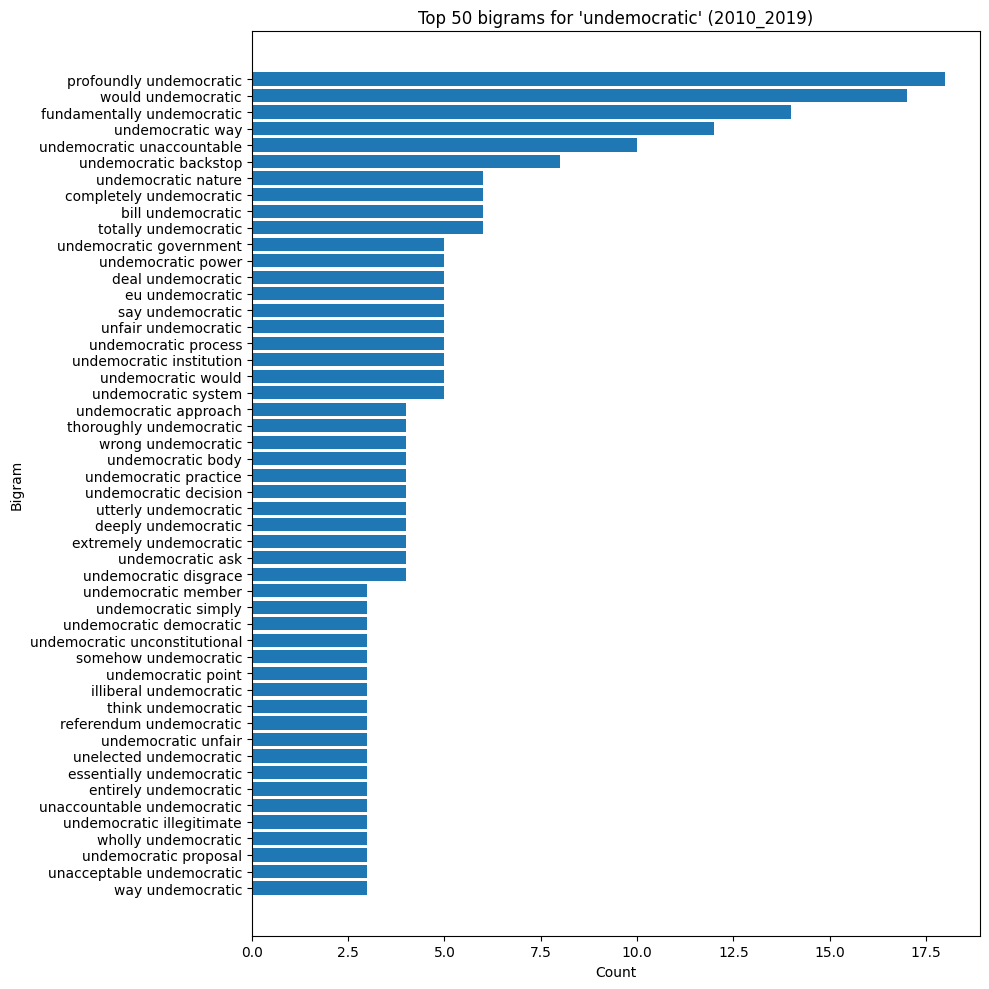

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascist_1980_1989_top50_bigrams.png


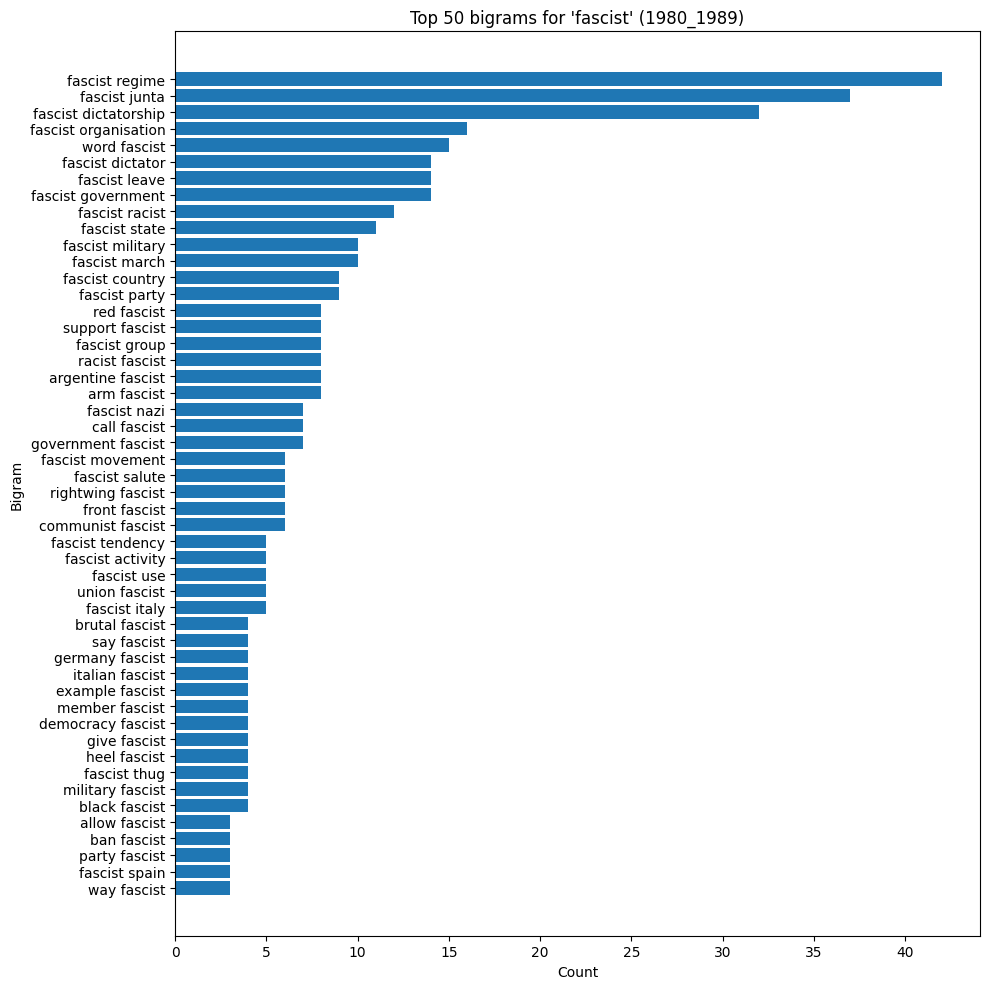

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascist_1990_1999_top50_bigrams.png


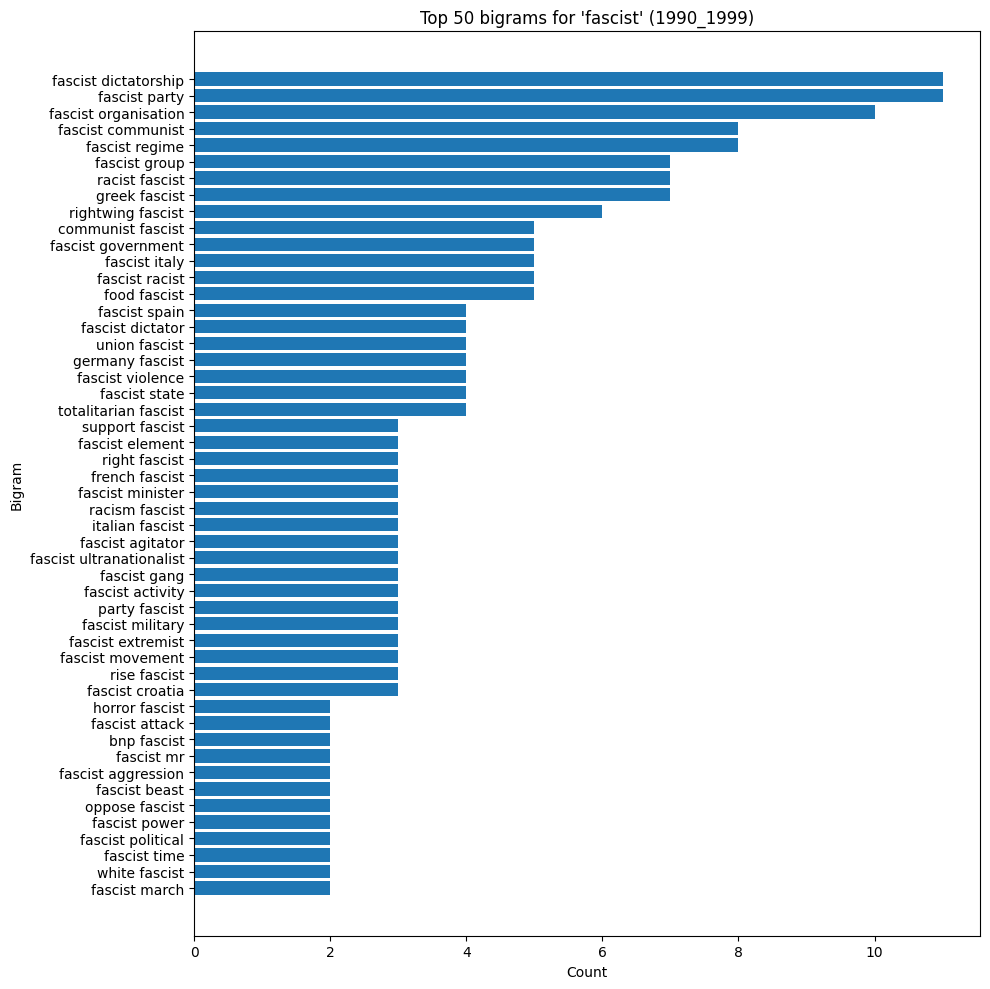

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascist_2000_2009_top50_bigrams.png


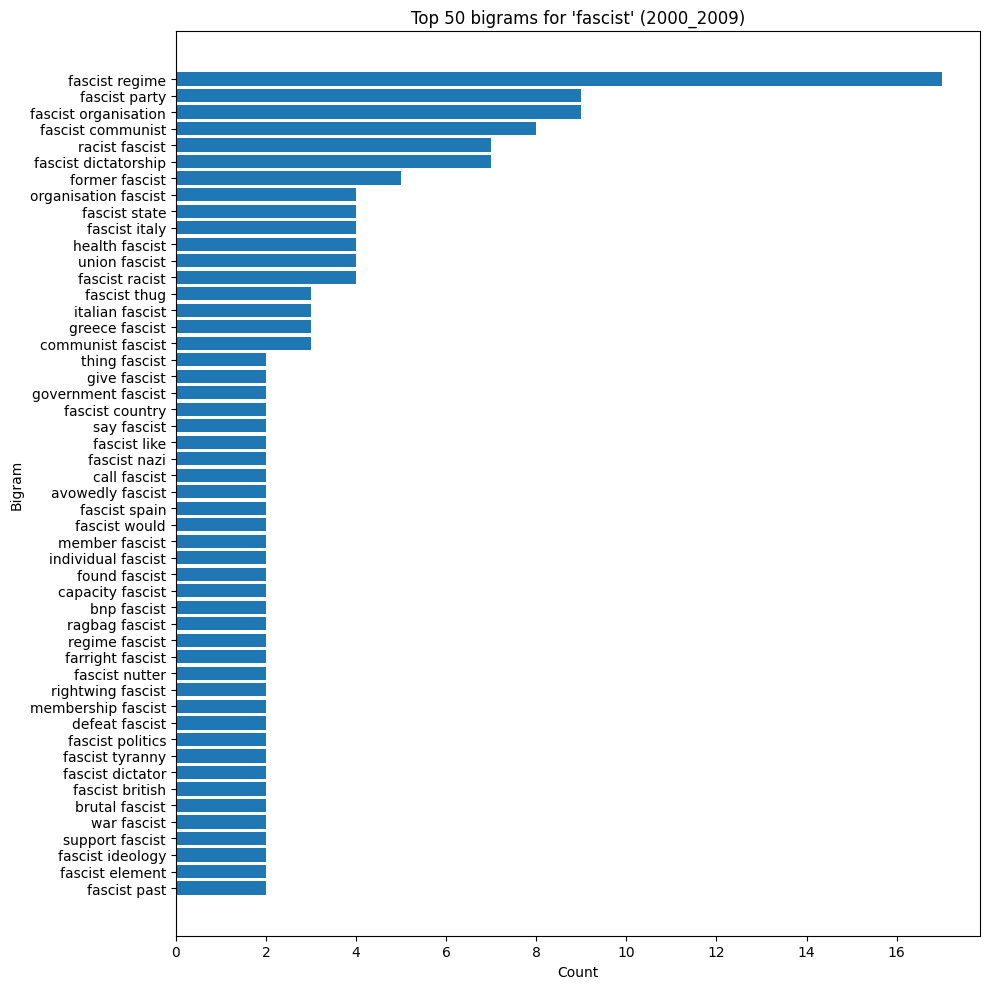

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascist_2010_2019_top50_bigrams.png


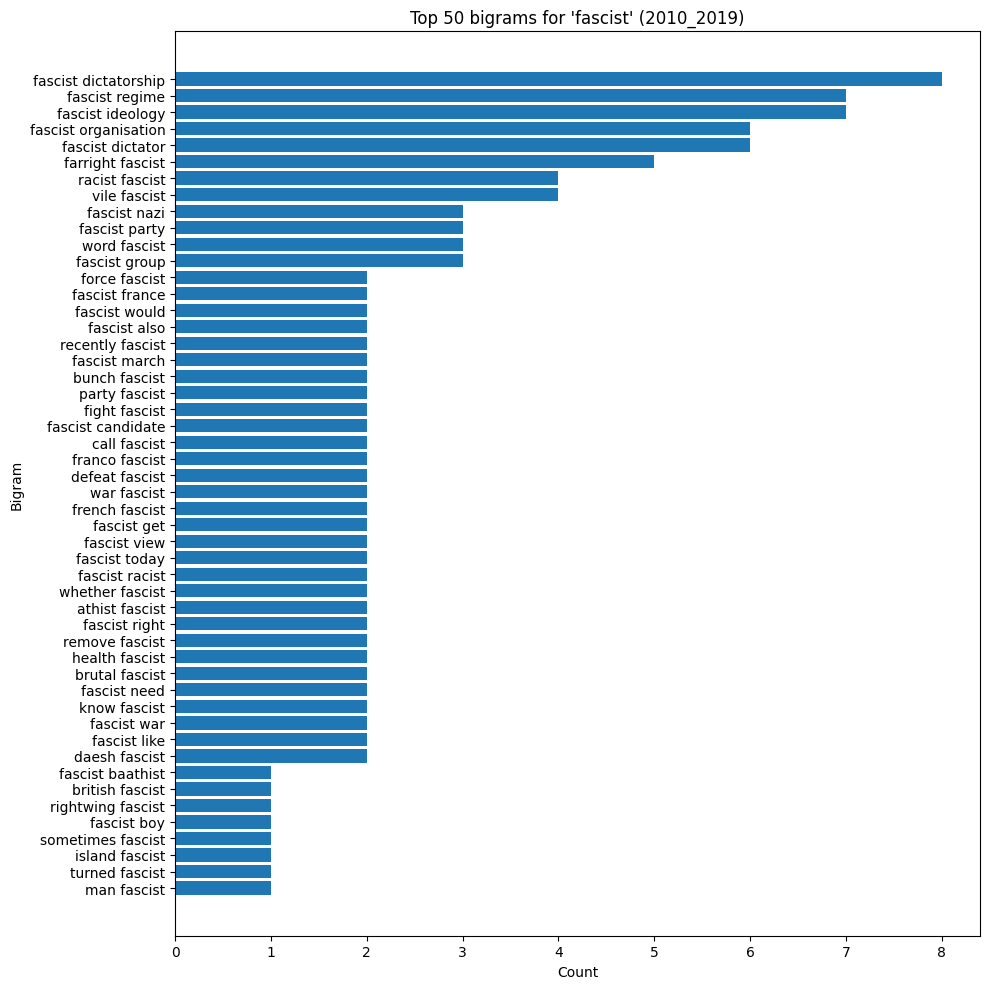

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascism_1980_1989_top50_bigrams.png


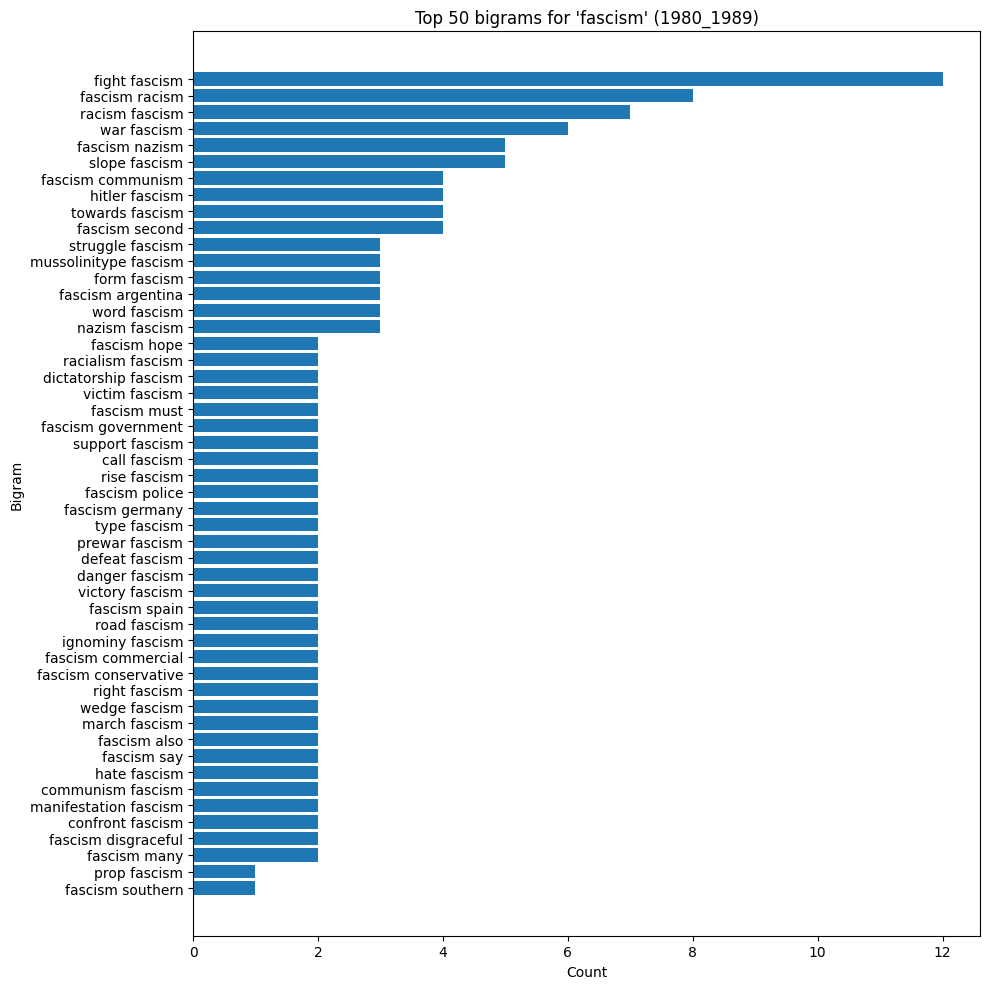

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascism_1990_1999_top50_bigrams.png


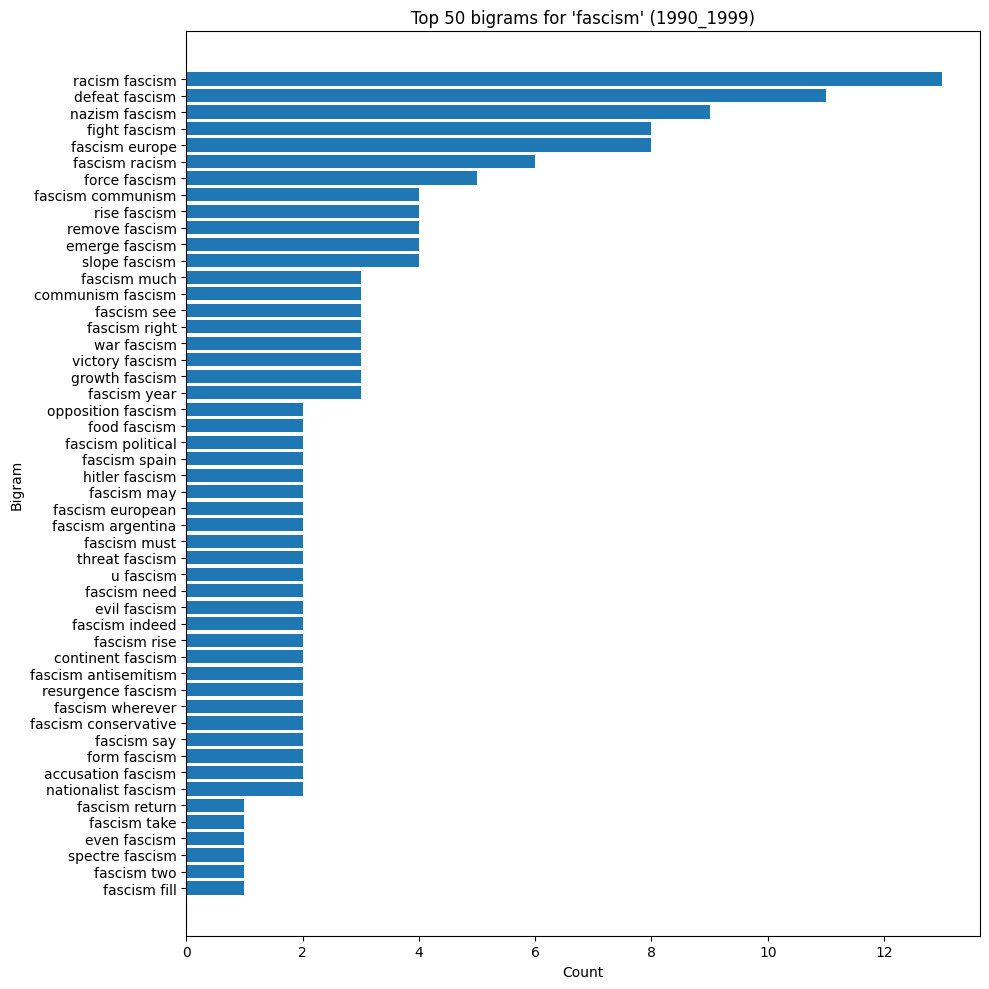

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascism_2000_2009_top50_bigrams.png


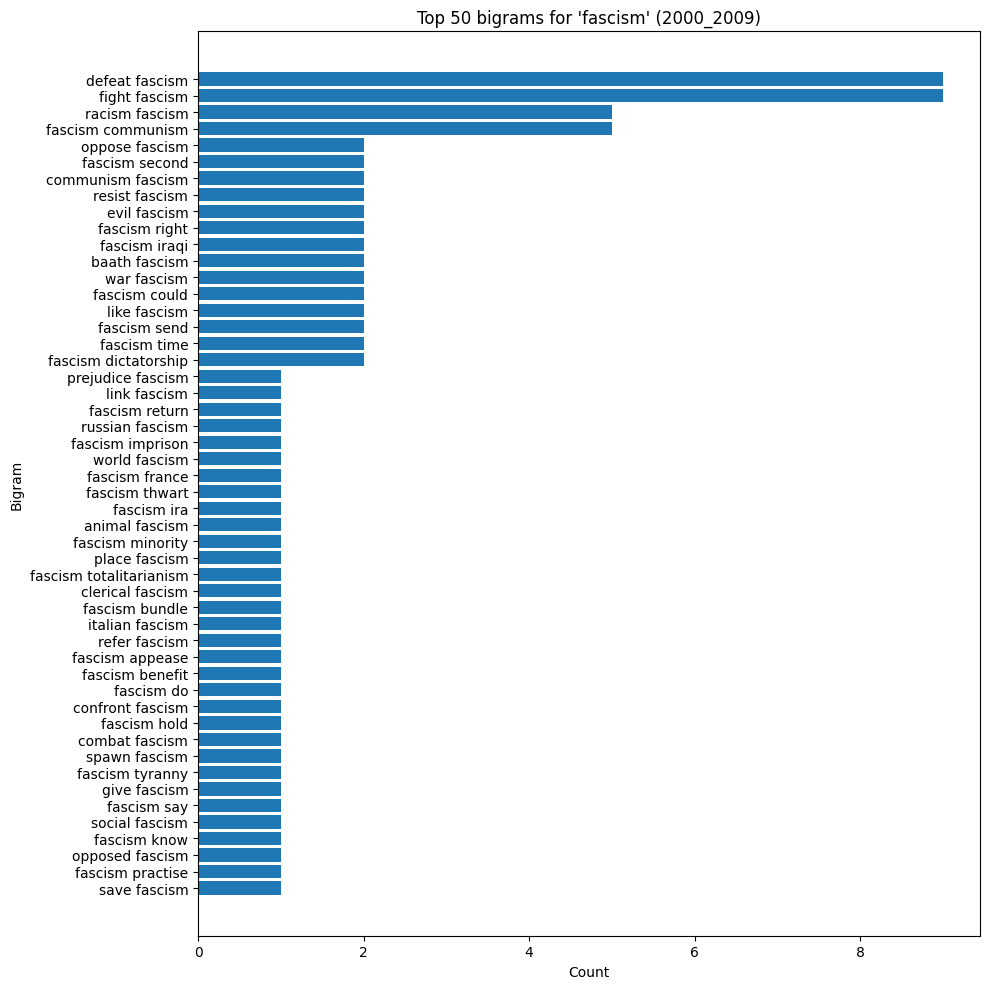

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/fascism_2010_2019_top50_bigrams.png


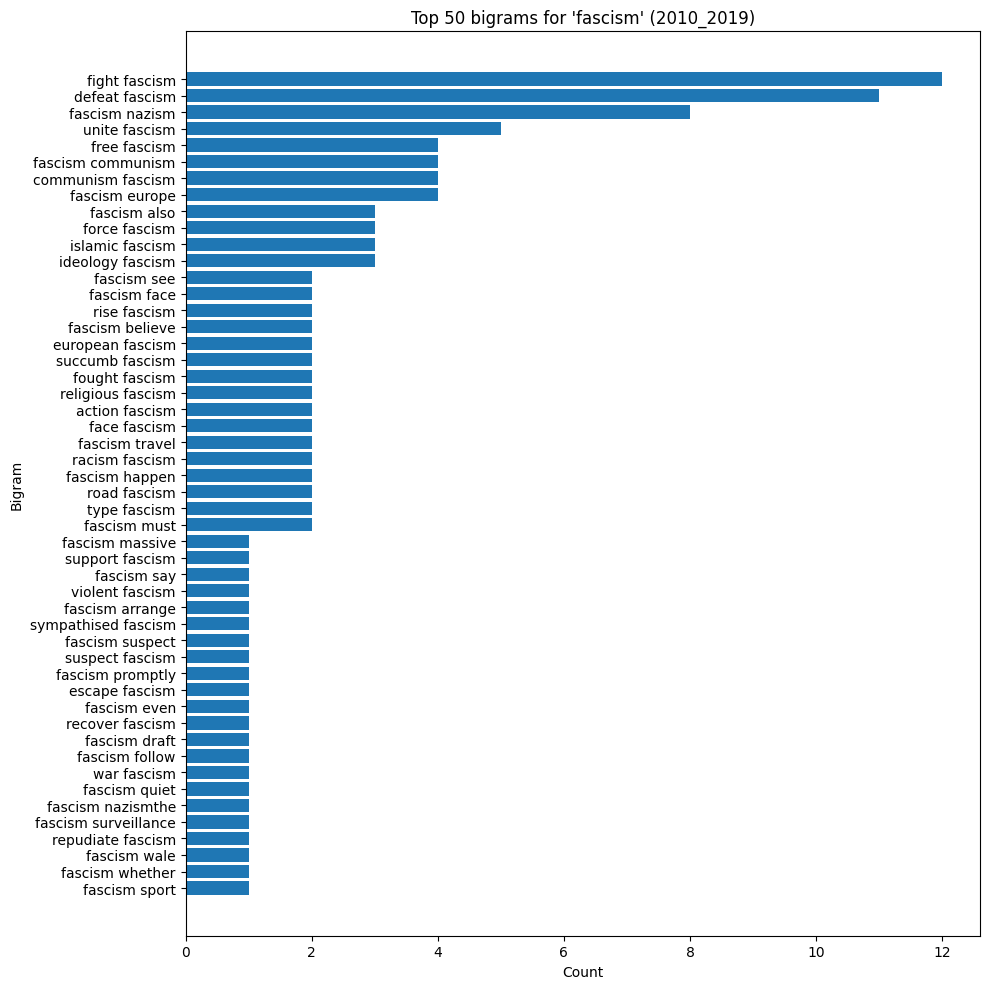

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/crisis_1980_1989_top50_bigrams.png


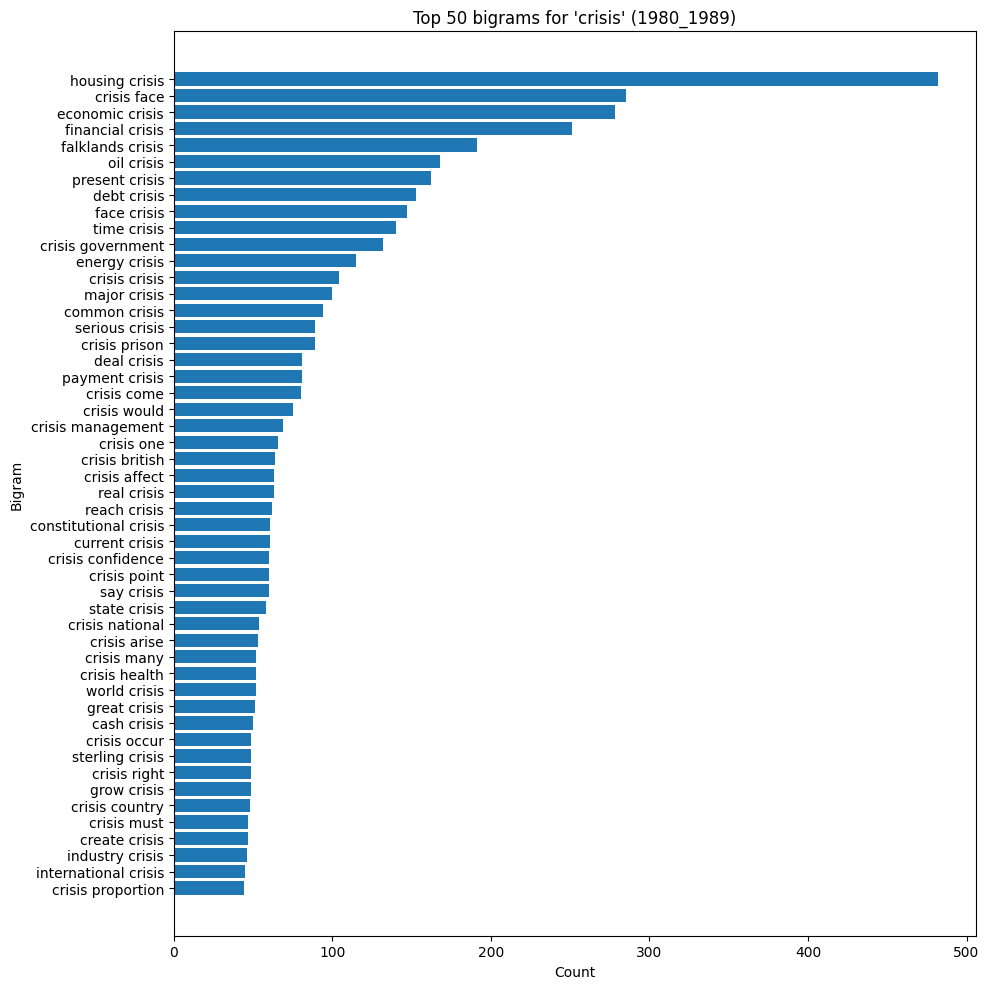

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/crisis_1990_1999_top50_bigrams.png


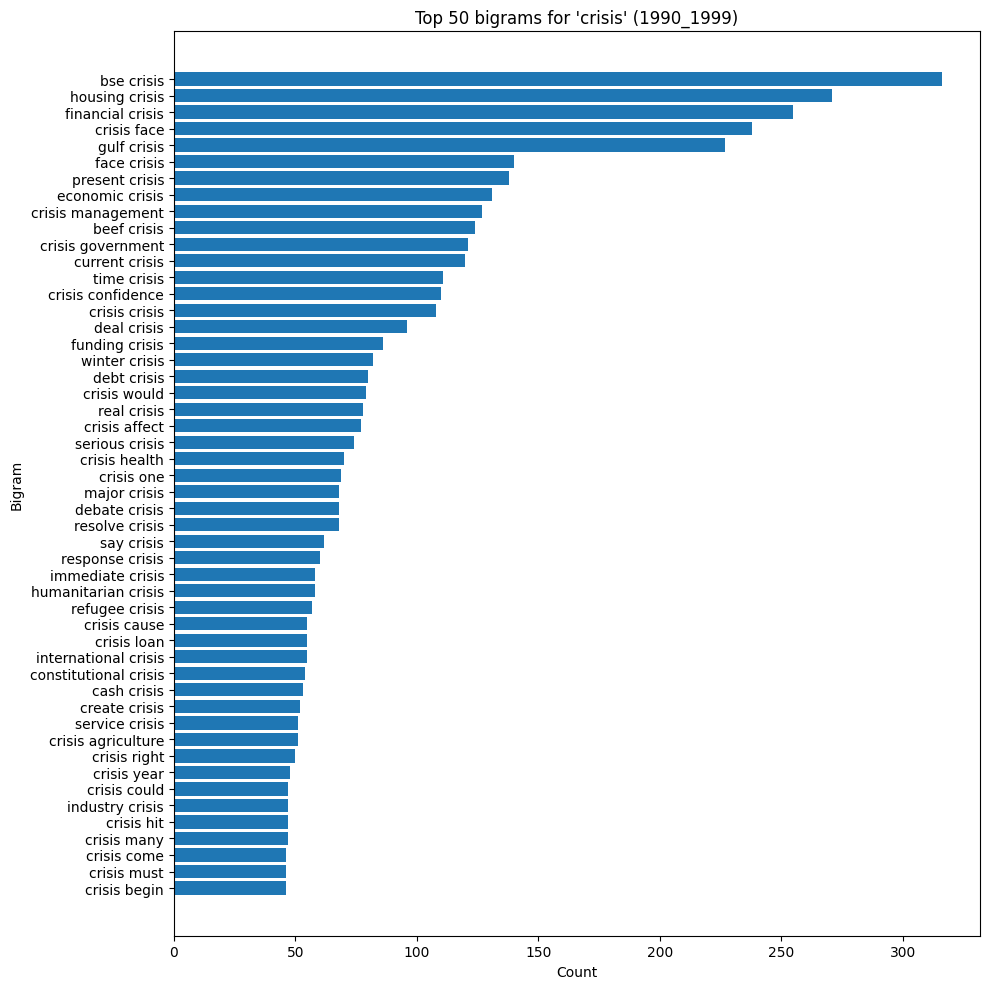

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/crisis_2000_2009_top50_bigrams.png


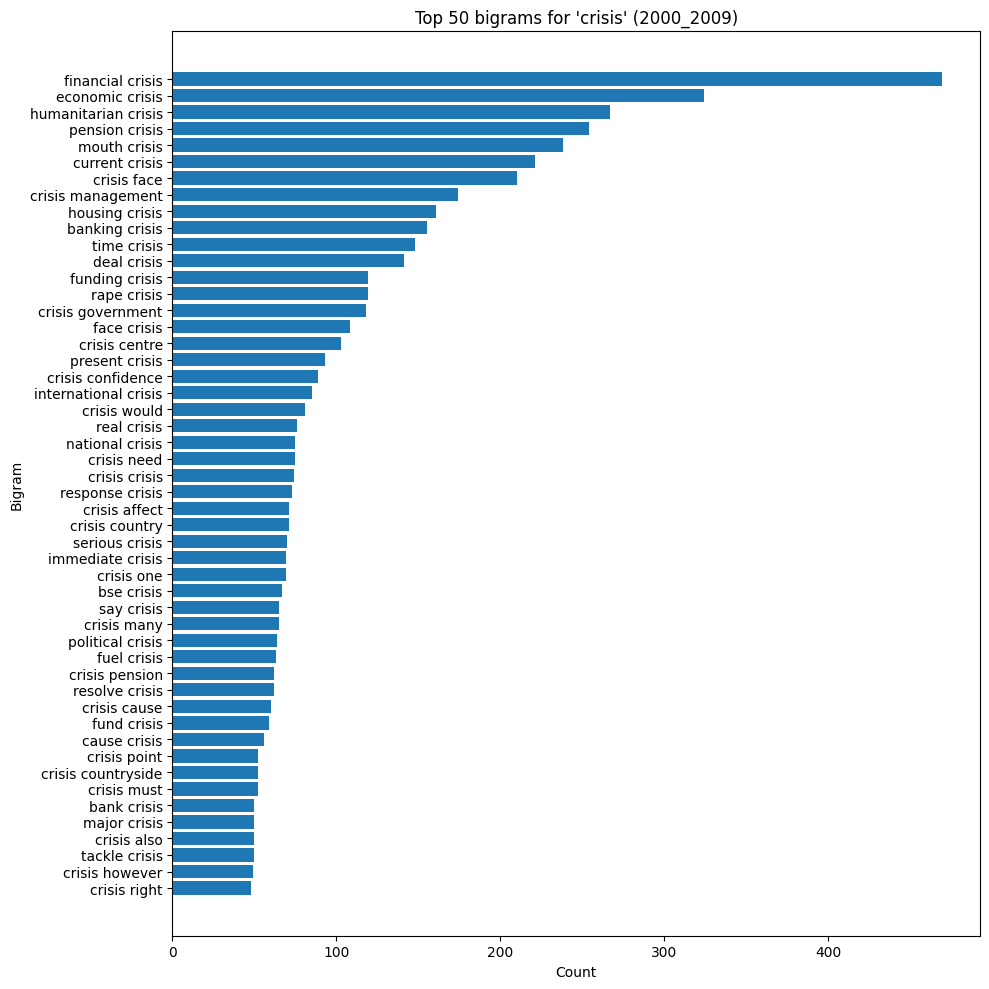

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/crisis_2010_2019_top50_bigrams.png


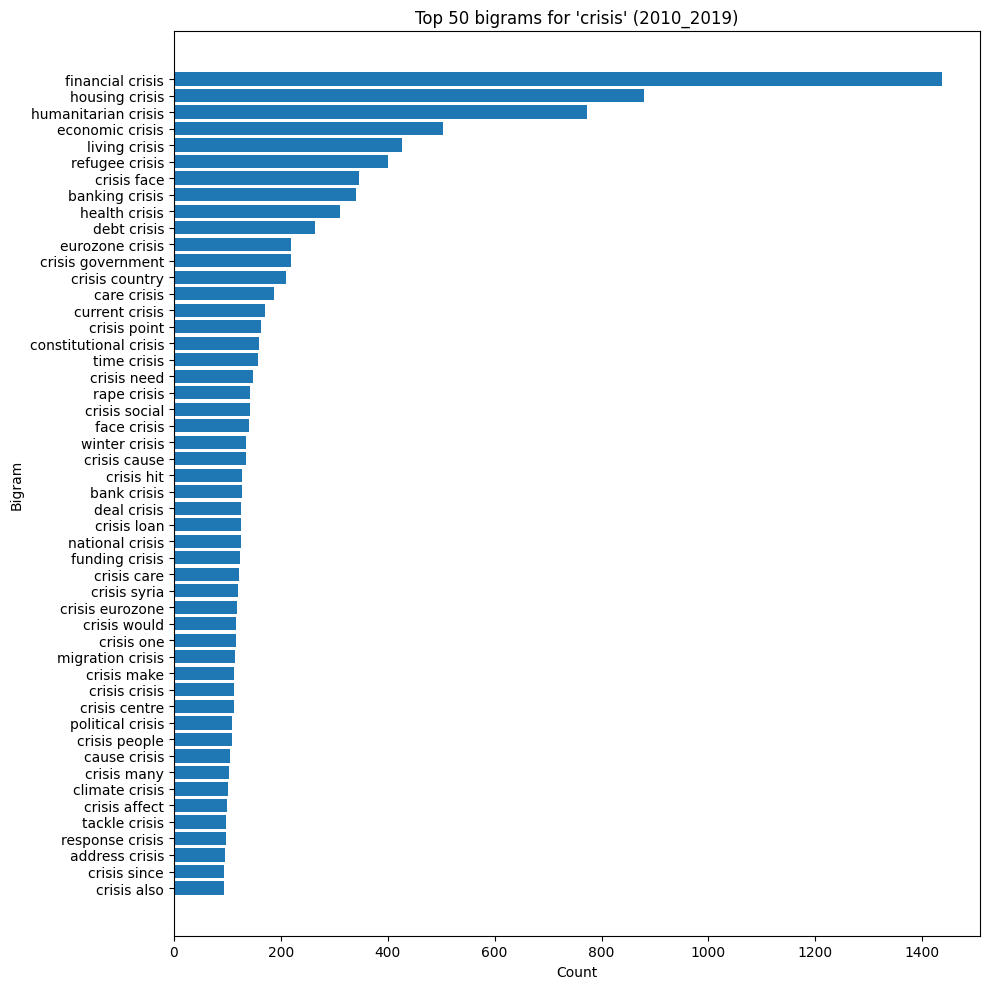

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/critical_1980_1989_top50_bigrams.png


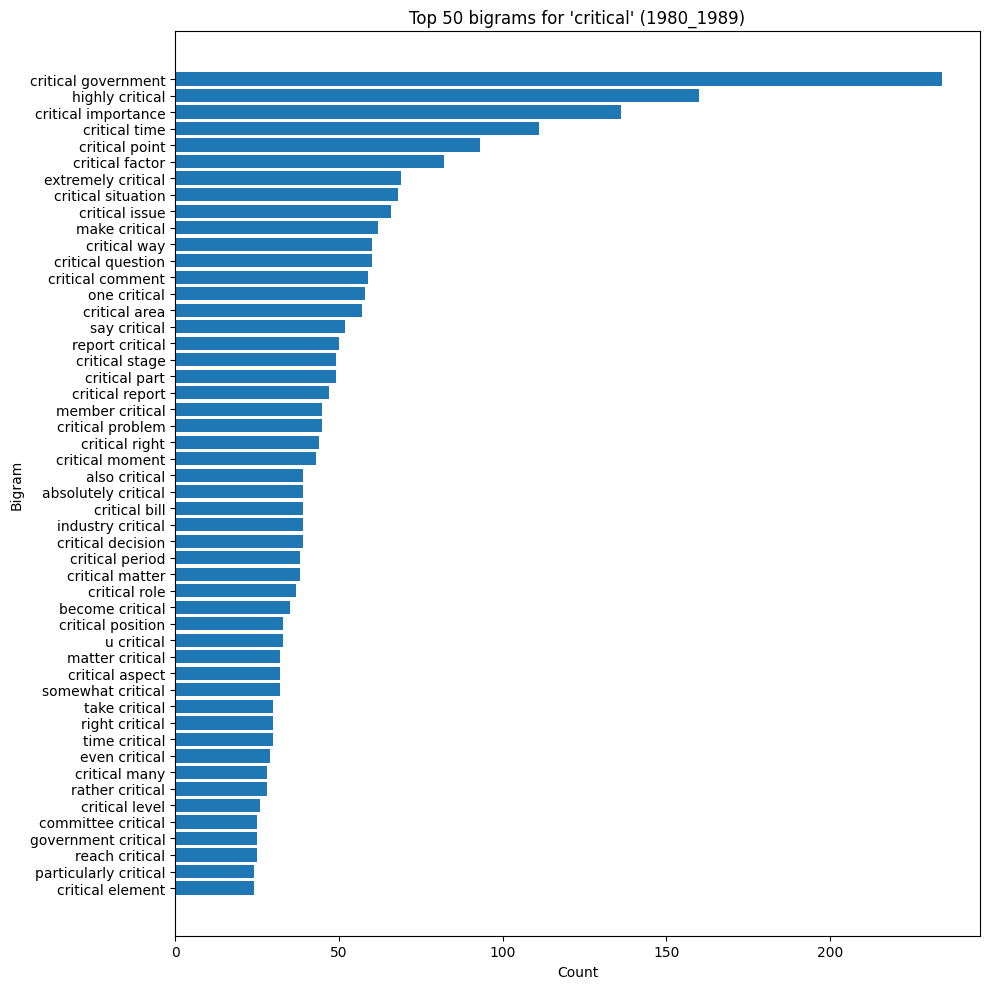

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/critical_1990_1999_top50_bigrams.png


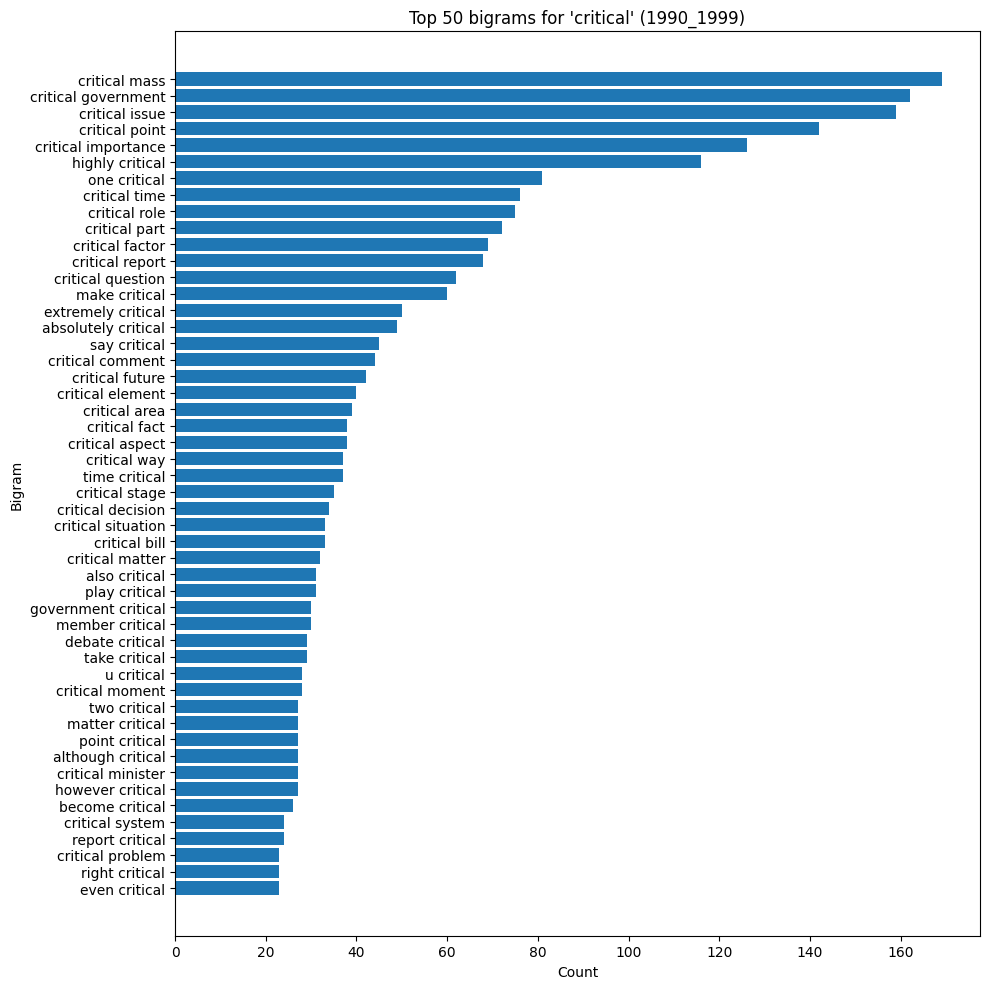

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/critical_2000_2009_top50_bigrams.png


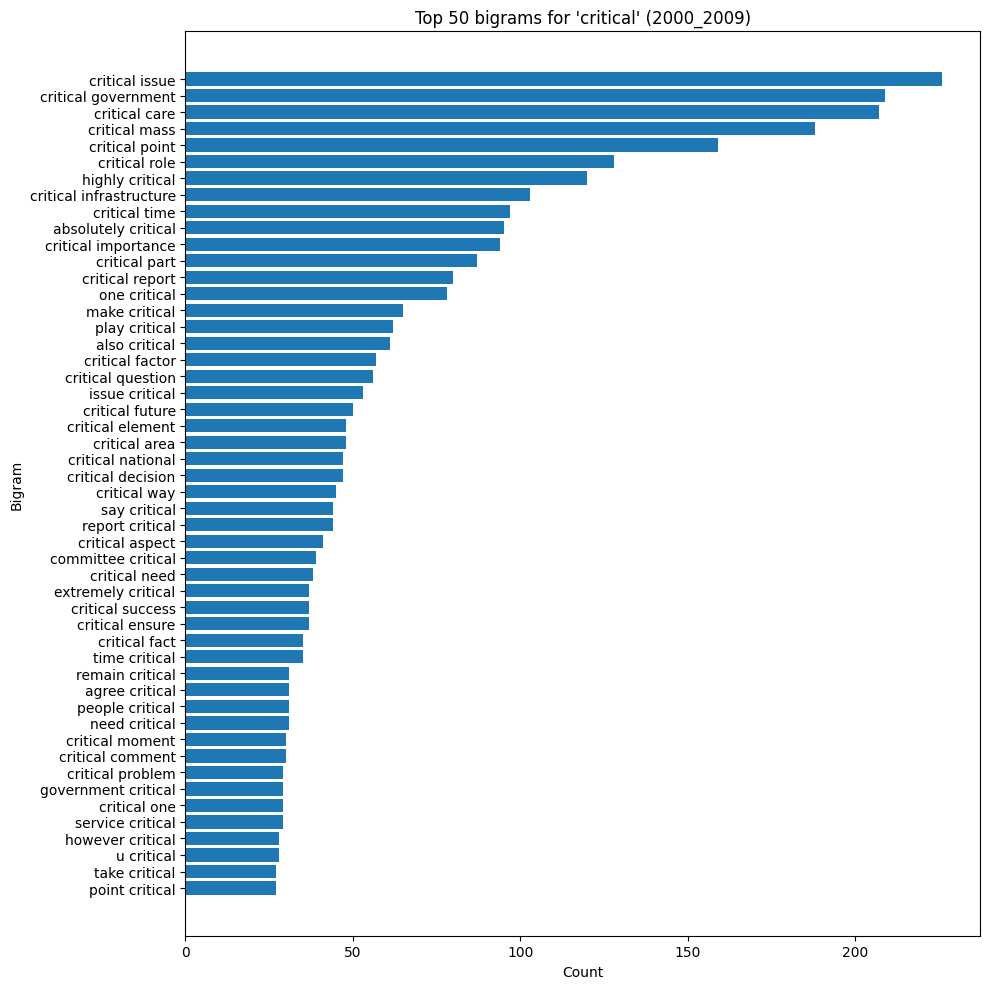

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures/critical_2010_2019_top50_bigrams.png


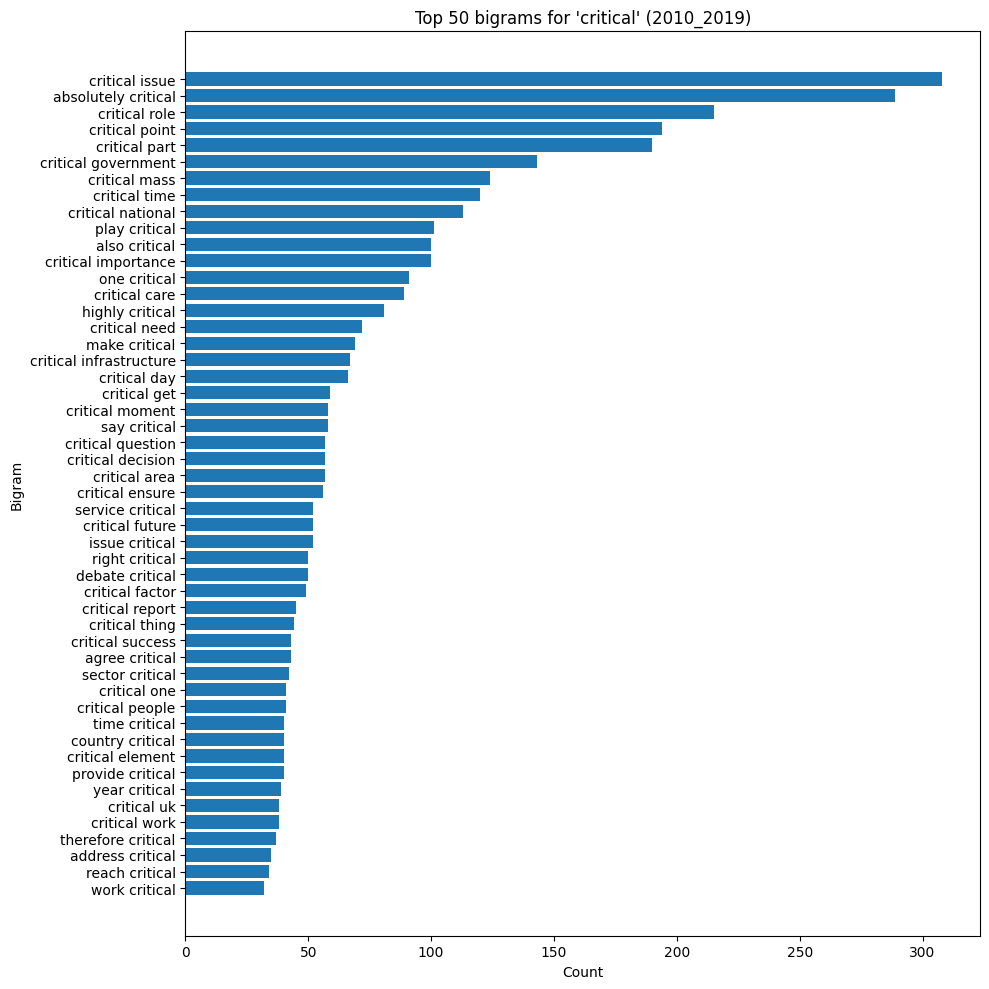

In [5]:
top_n = 50

figure_output_folder = "/Users/inqfinity/mip/newdecades_bigram_figures"
os.makedirs(figure_output_folder, exist_ok=True)
for target_word in words_to_find:

    for period_name in periods.keys():
        csv_path = f"{output_folder}/{target_word}_{period_name}_top50_bigrams.csv"
        df_plot = pd.read_csv(csv_path)

        if df_plot.empty:
            print(f"No bigrams found for {target_word} | {period_name}")
            continue

        df_plot = df_plot.head(top_n)
        df_plot = df_plot.sort_values("count", ascending=True)  #top freqs first

        plt.figure(figsize=(10, 10))

        plt.barh(df_plot["bigram"], df_plot["count"])

        plt.title(f"Top {top_n} bigrams for '{target_word}' ({period_name})")
        plt.xlabel("Count")
        plt.ylabel("Bigram")

        plt.tight_layout()

        figure_path = (f"{figure_output_folder}/" f"{target_word}_{period_name}_top50_bigrams.png")

        plt.savefig(figure_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure: {figure_path}")
        plt.show()
        plt.close()

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democratic_1980_1989_top50_bigrams_percent.png


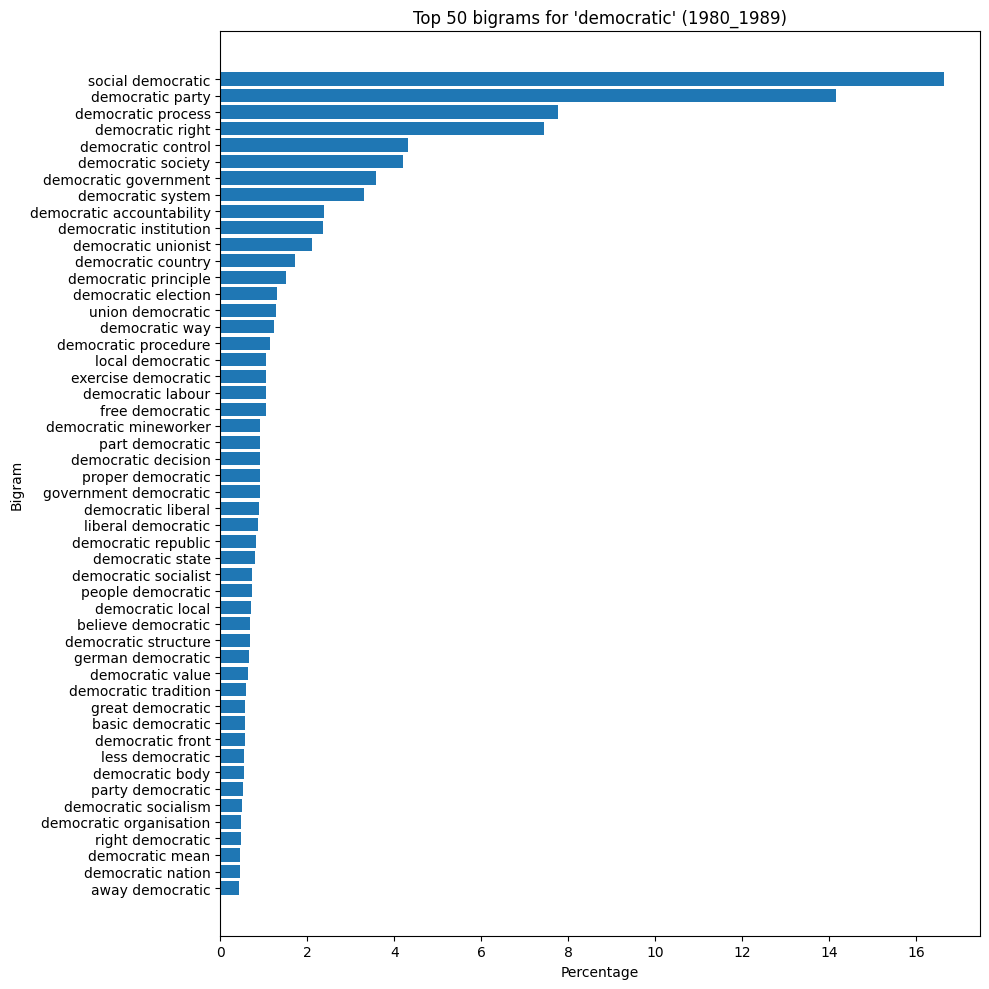

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democratic_1990_1999_top50_bigrams_percent.png


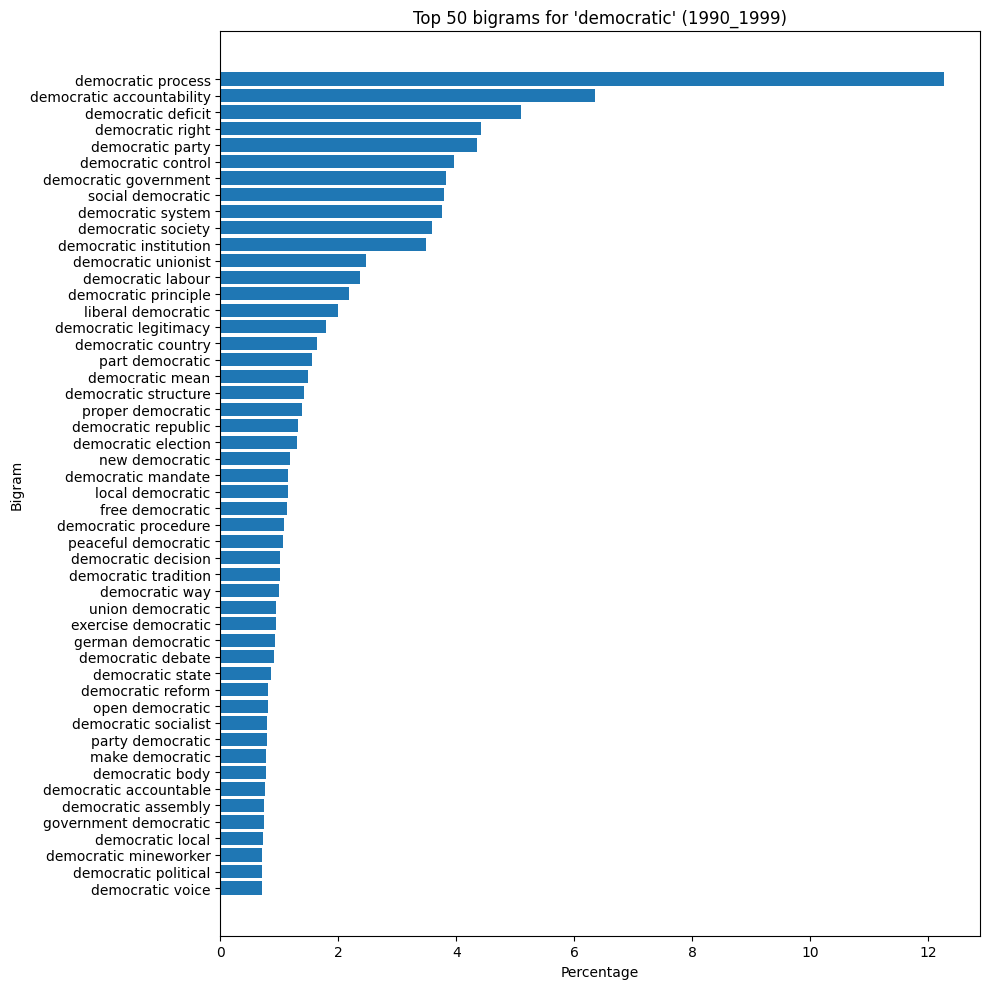

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democratic_2000_2009_top50_bigrams_percent.png


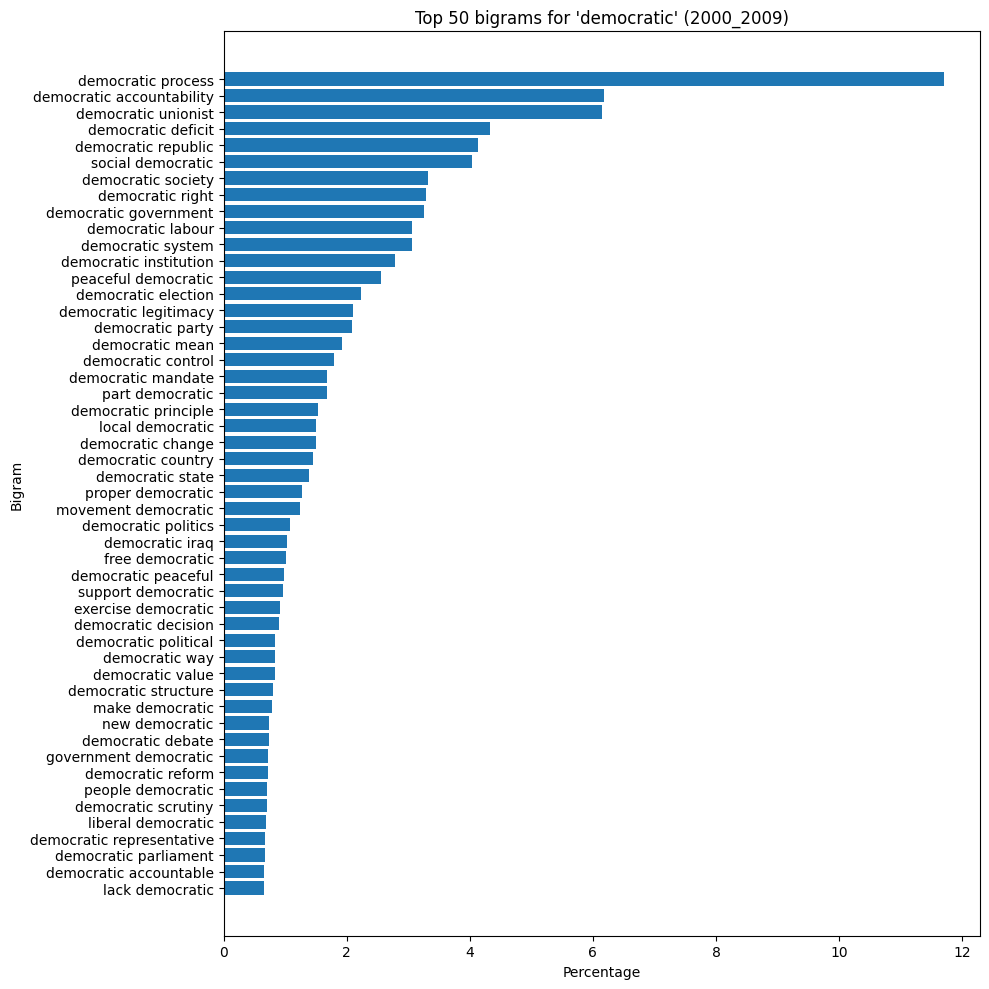

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democratic_2010_2019_top50_bigrams_percent.png


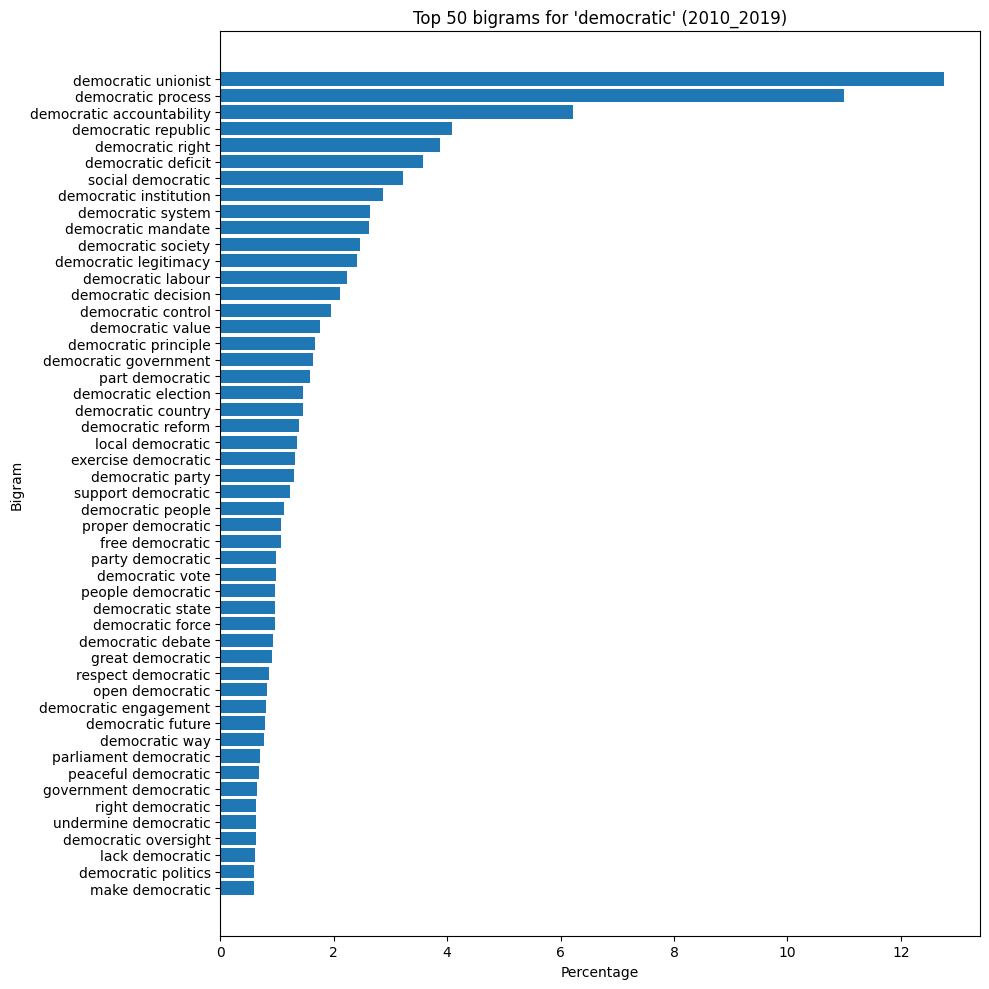

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democracy_1980_1989_top50_bigrams_percent.png


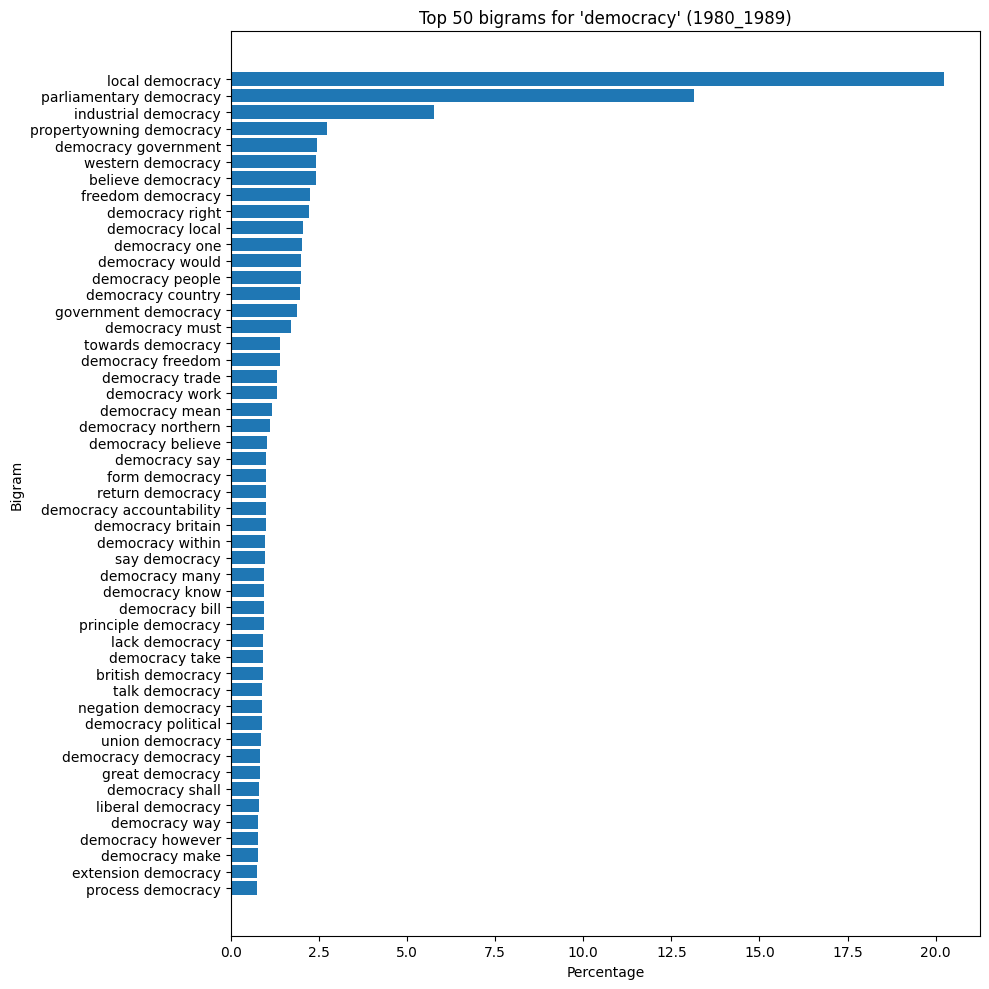

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democracy_1990_1999_top50_bigrams_percent.png


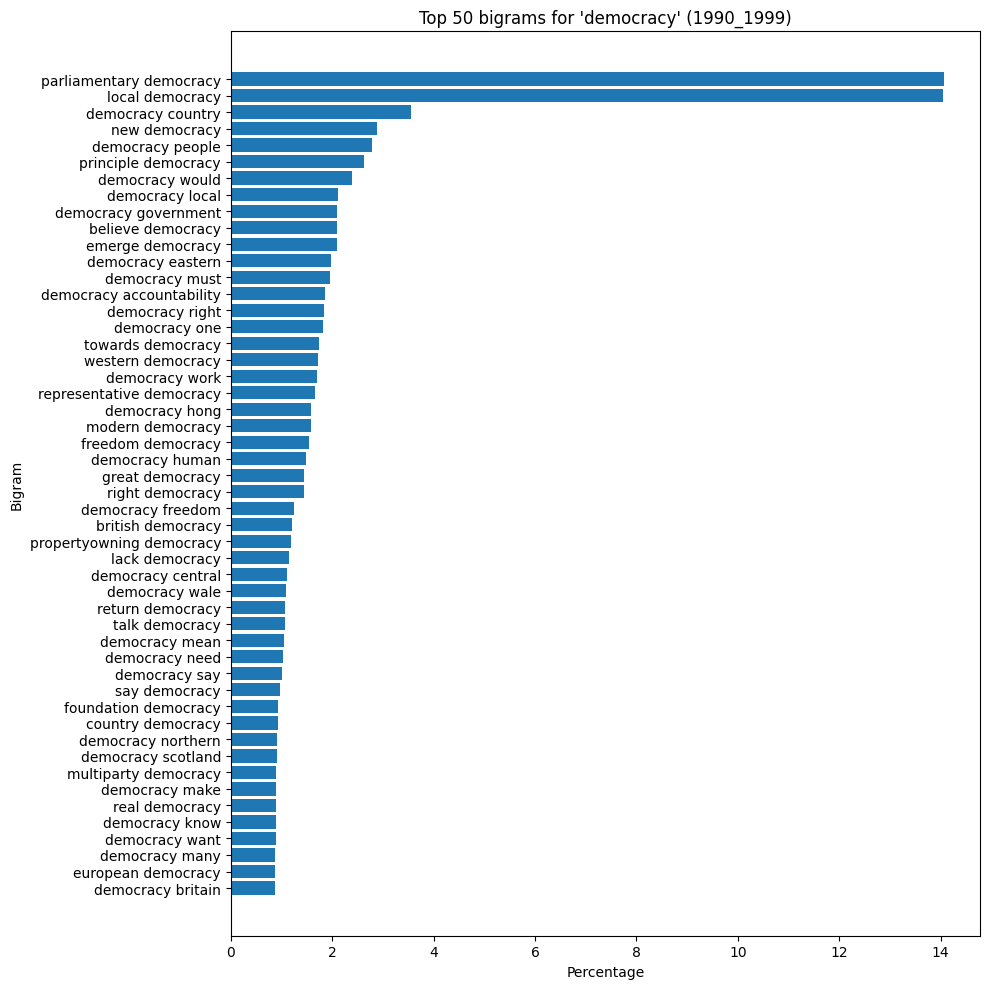

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democracy_2000_2009_top50_bigrams_percent.png


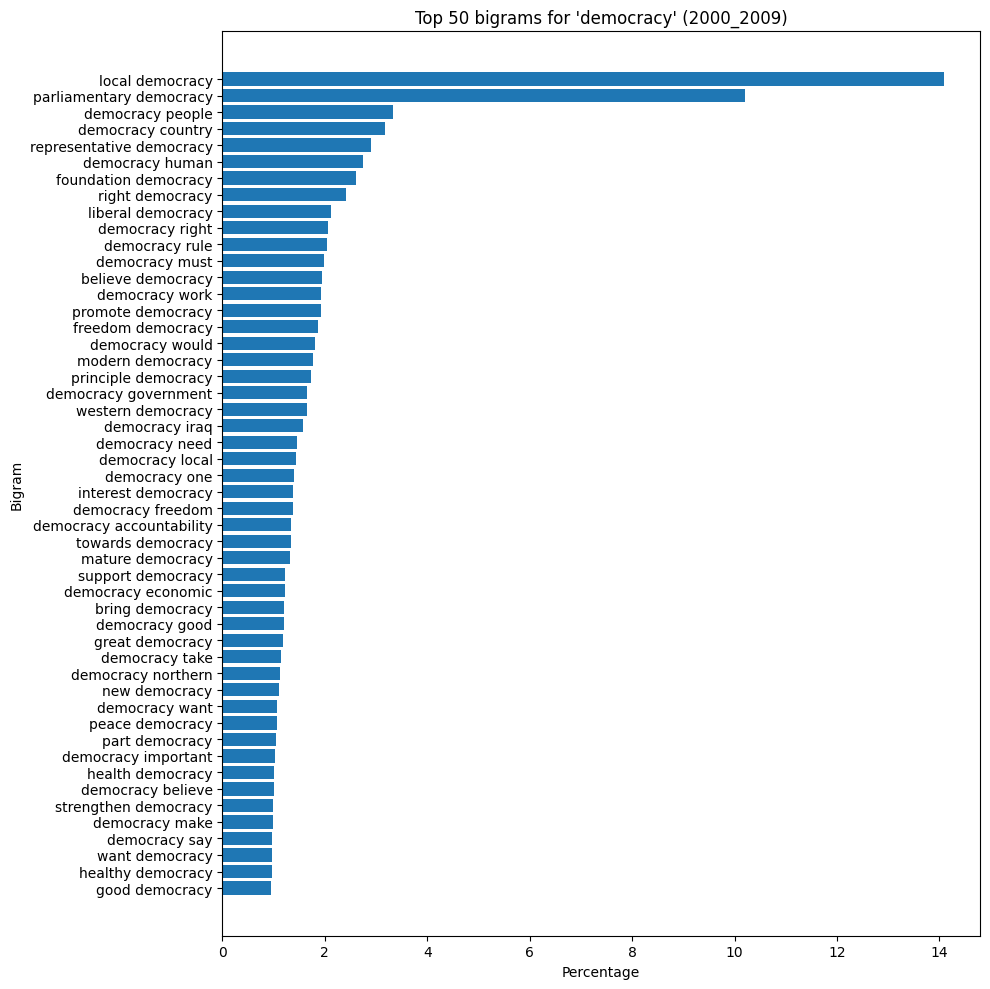

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/democracy_2010_2019_top50_bigrams_percent.png


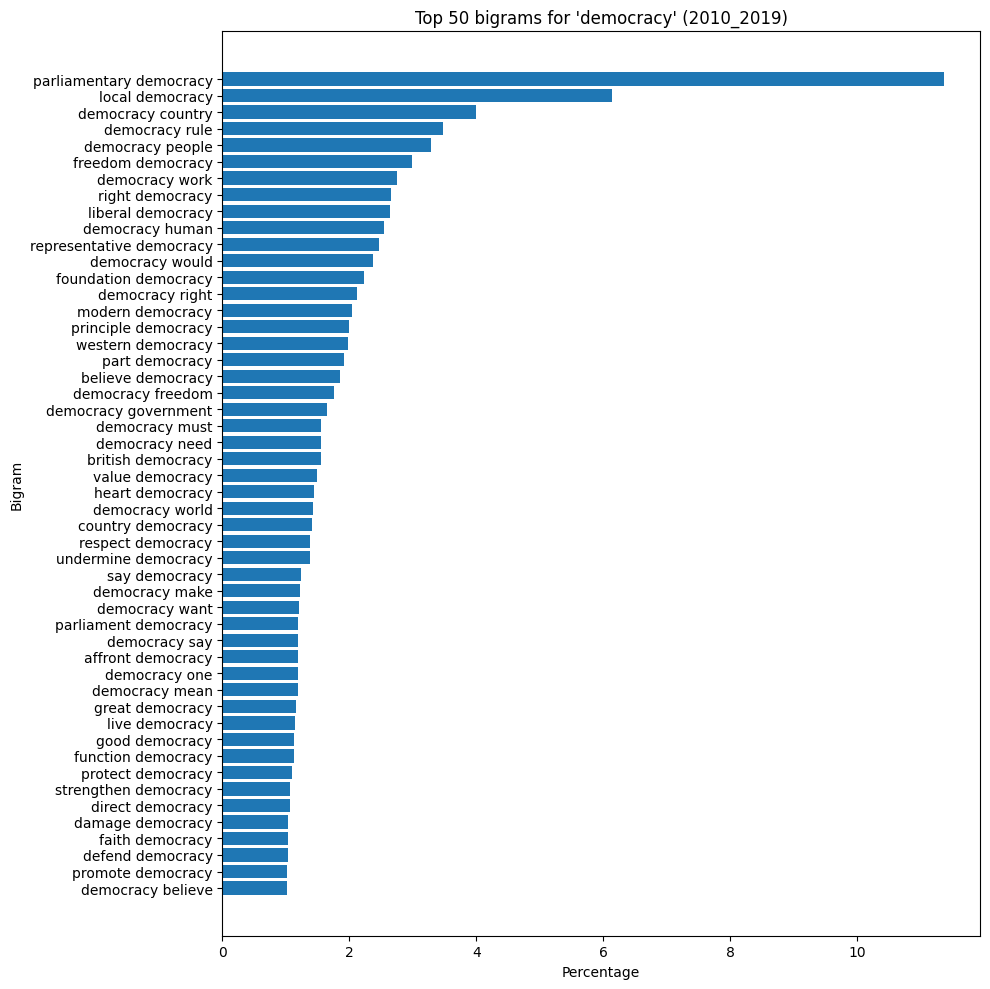

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/undemocratic_1980_1989_top50_bigrams_percent.png


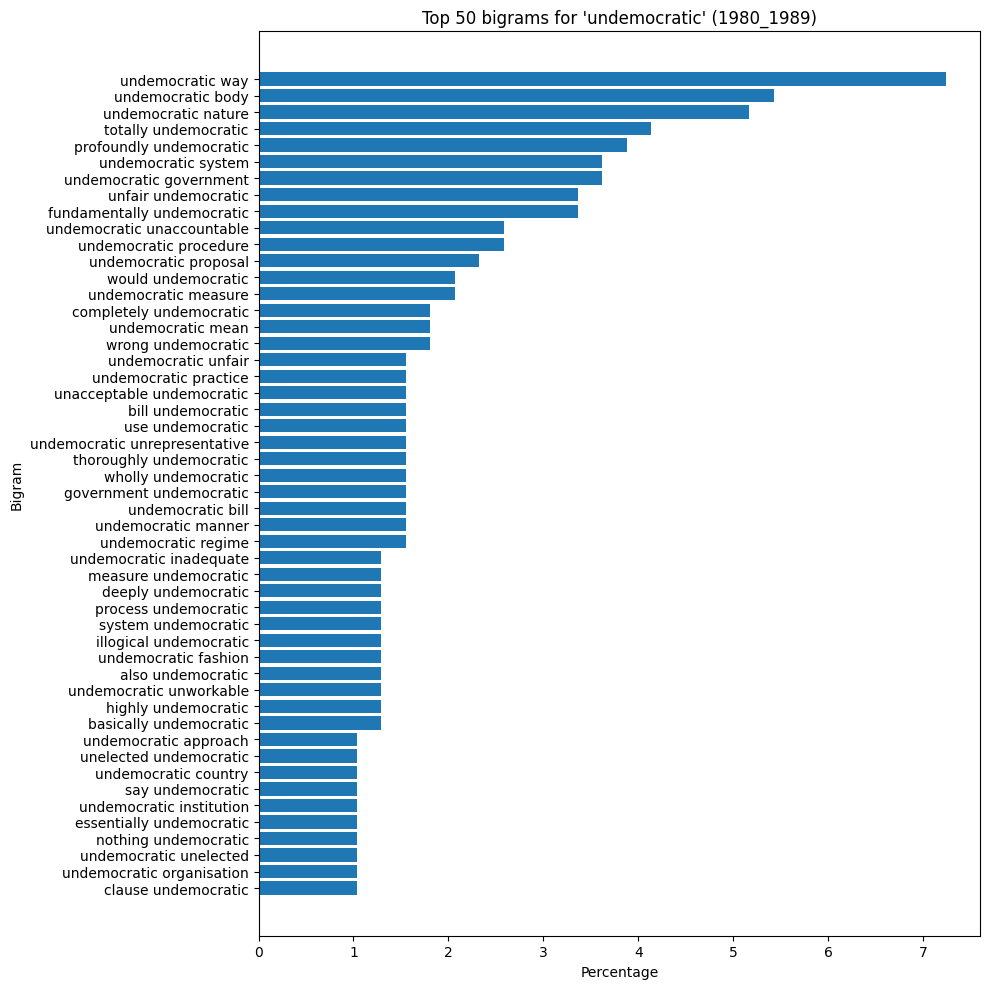

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/undemocratic_1990_1999_top50_bigrams_percent.png


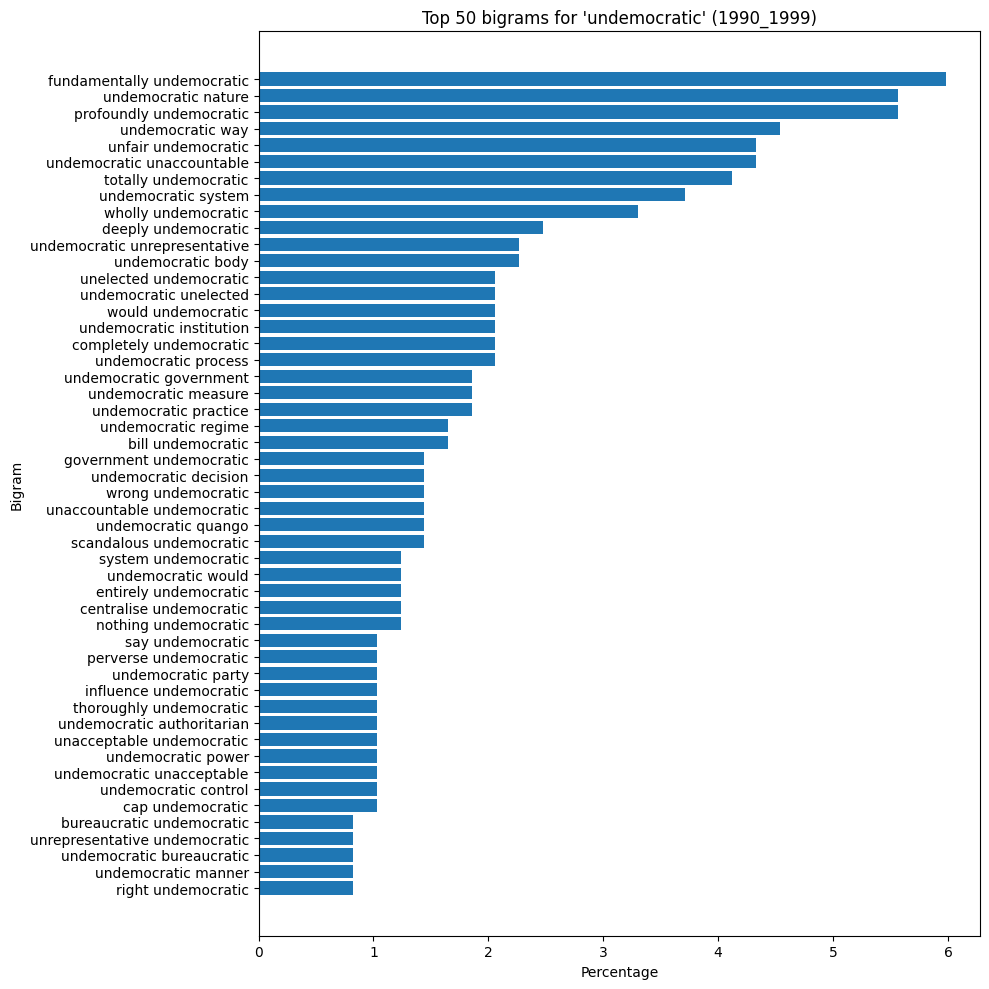

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/undemocratic_2000_2009_top50_bigrams_percent.png


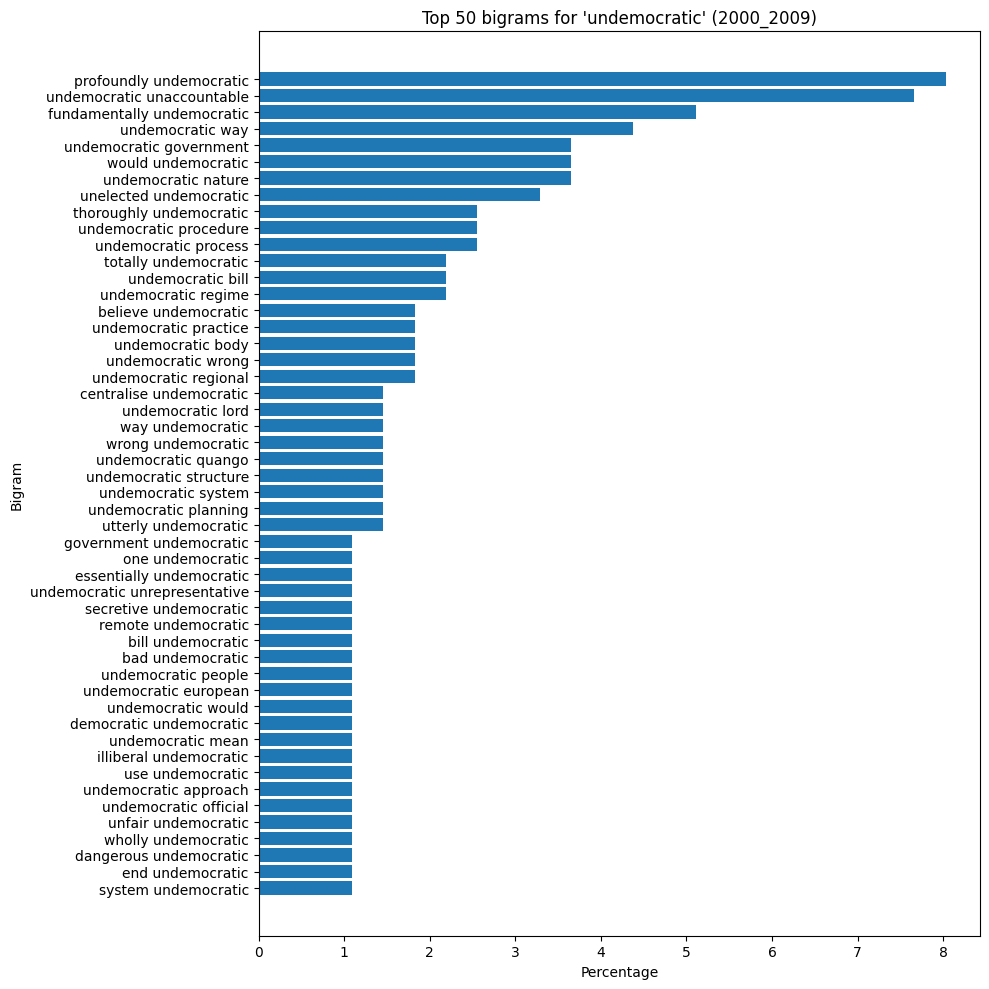

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/undemocratic_2010_2019_top50_bigrams_percent.png


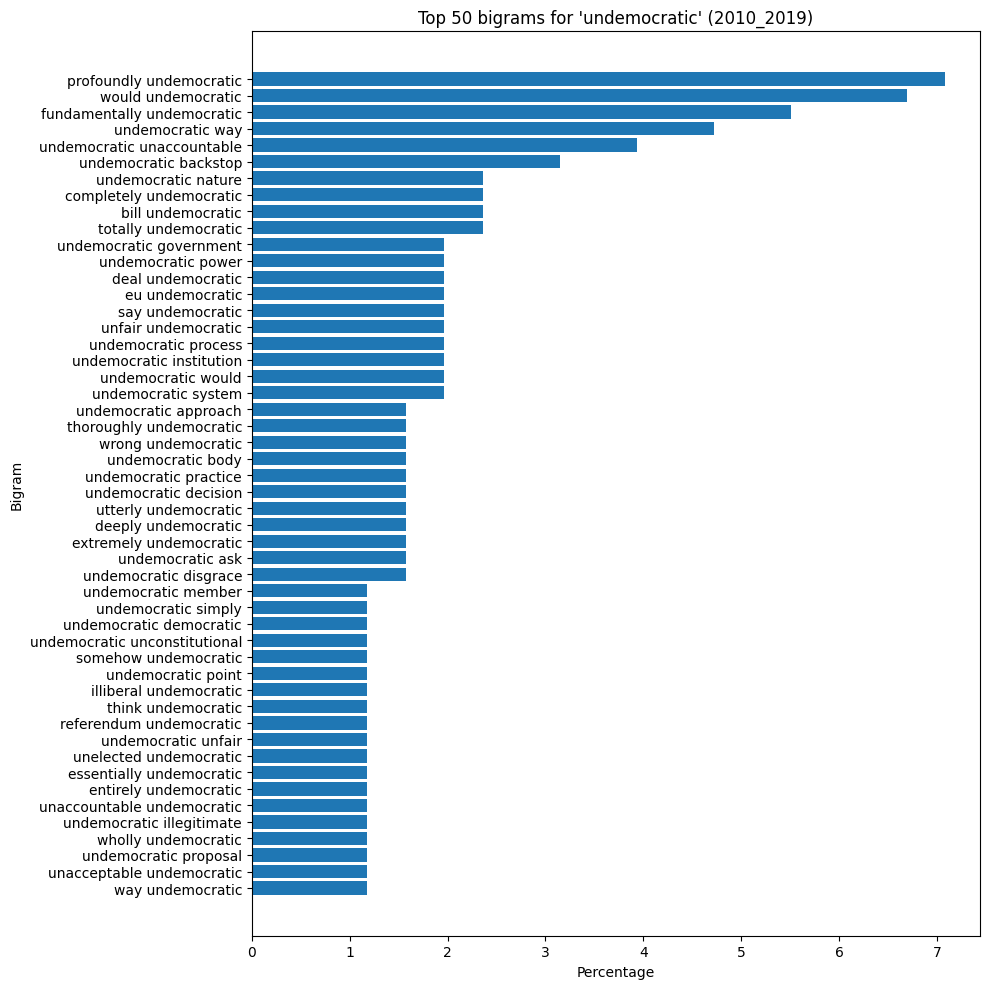

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascist_1980_1989_top50_bigrams_percent.png


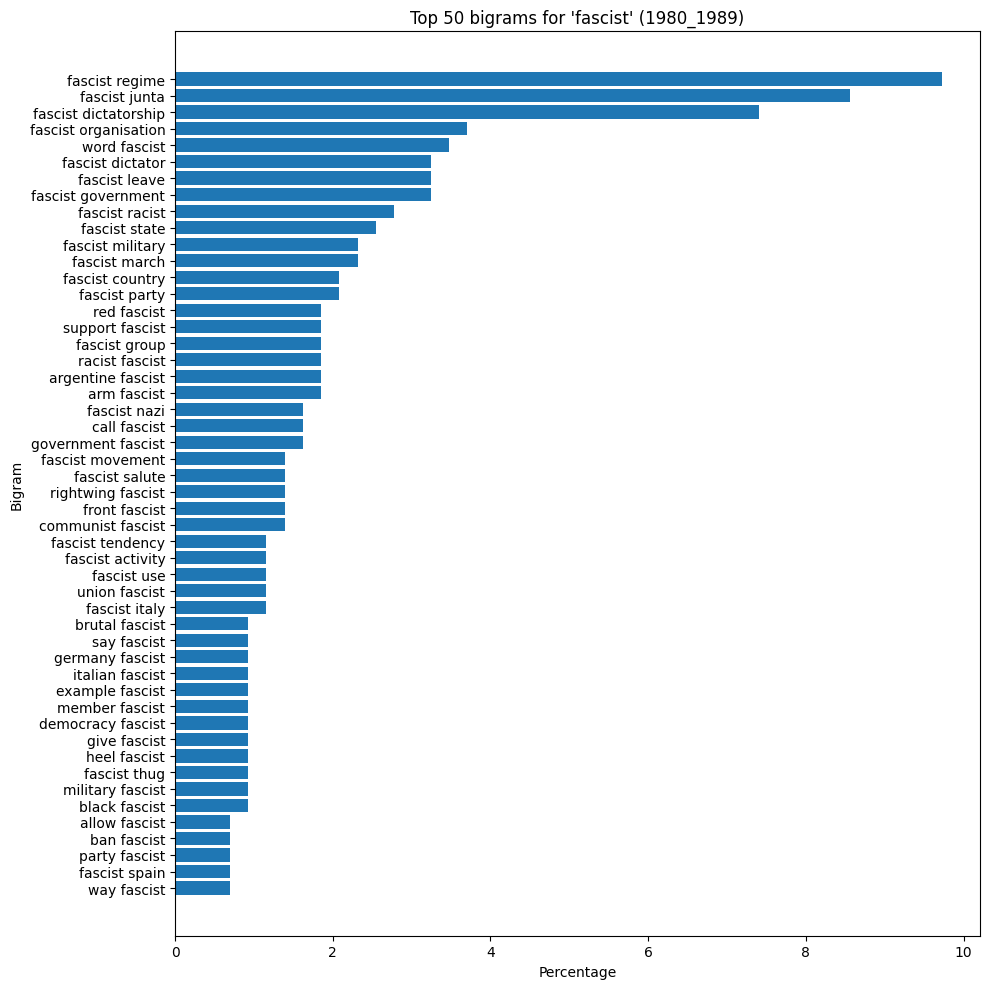

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascist_1990_1999_top50_bigrams_percent.png


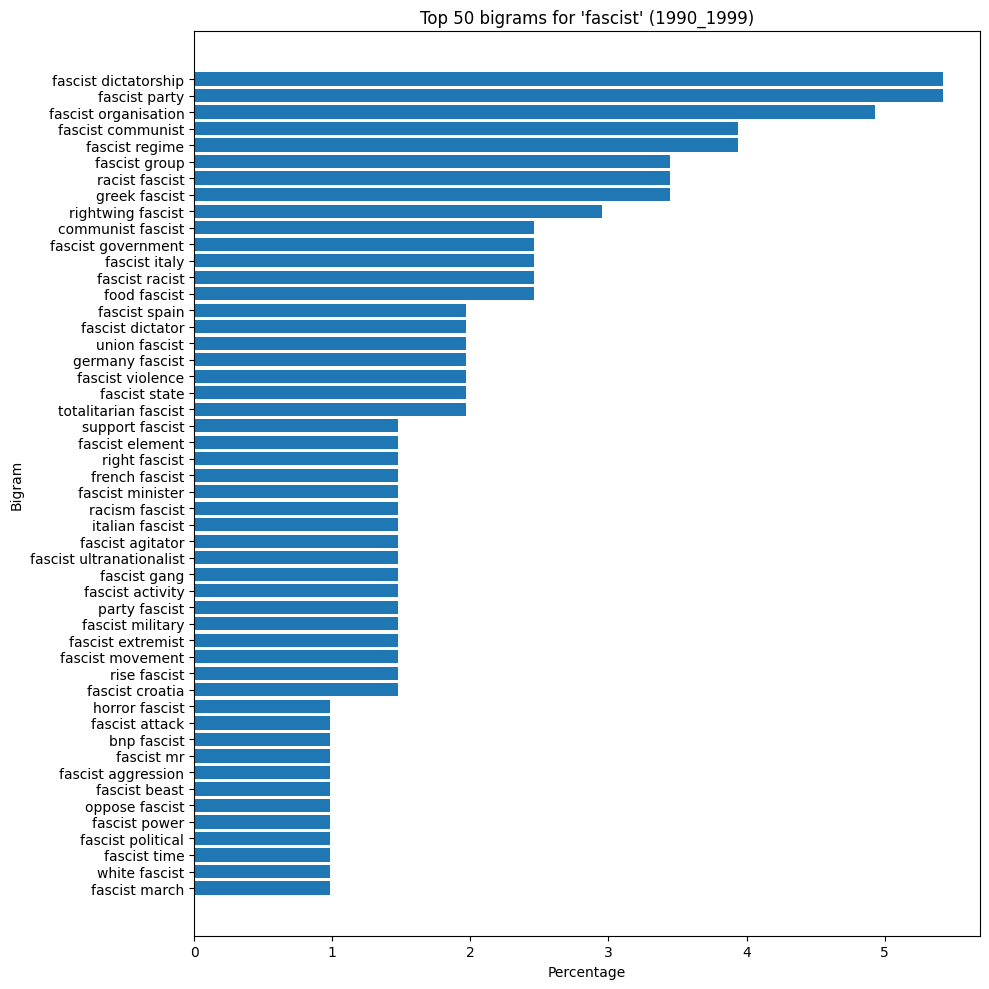

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascist_2000_2009_top50_bigrams_percent.png


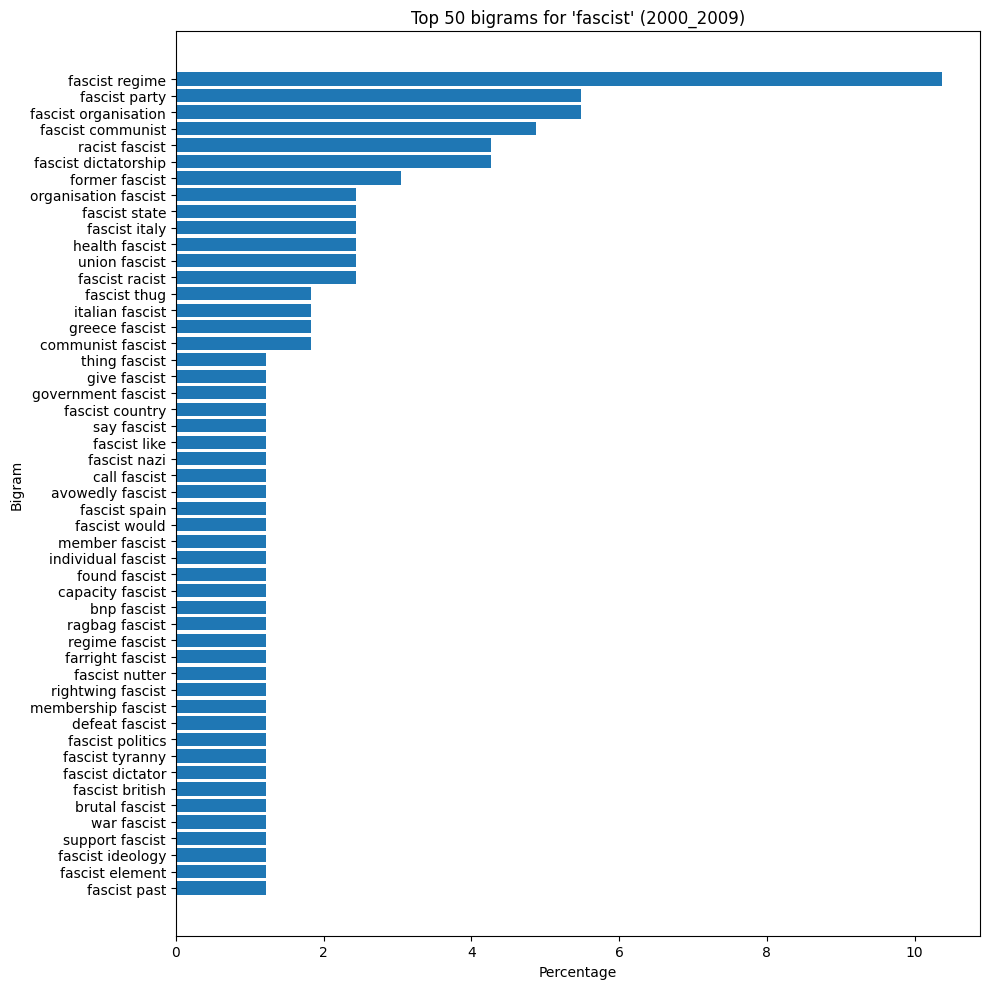

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascist_2010_2019_top50_bigrams_percent.png


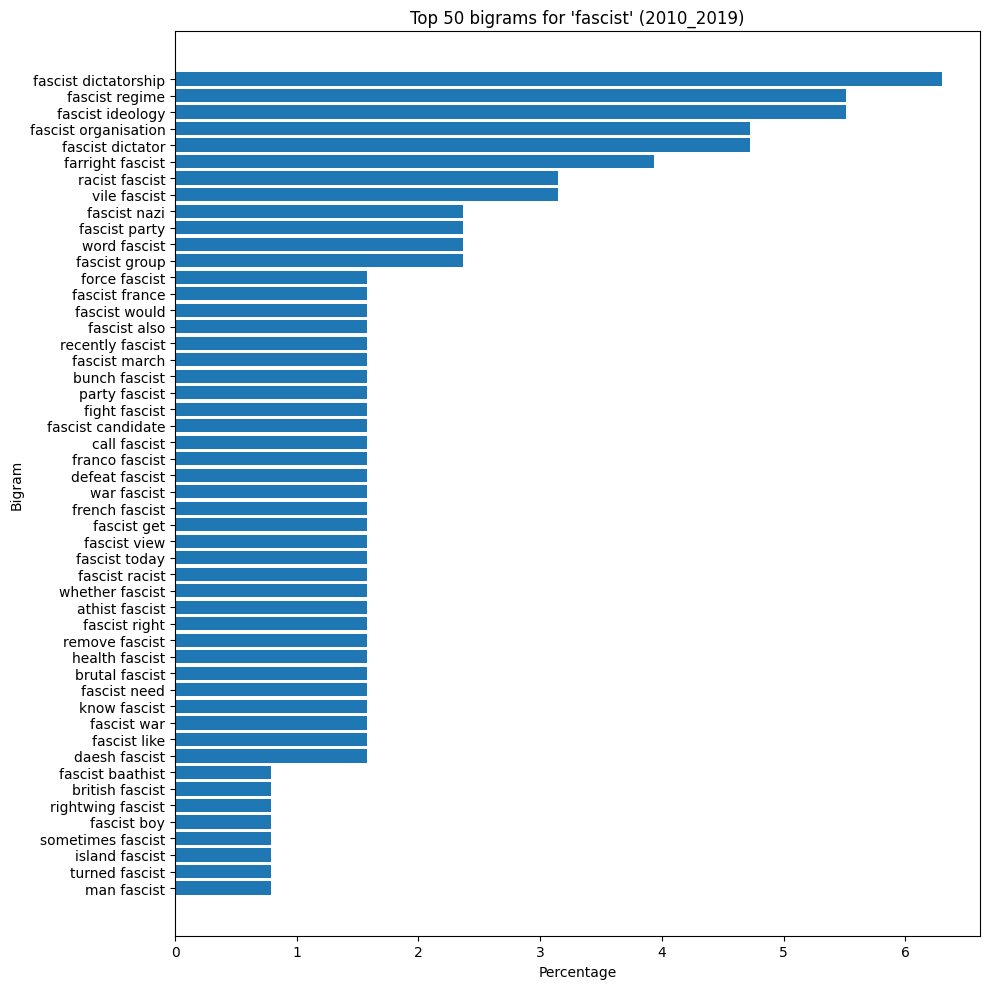

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascism_1980_1989_top50_bigrams_percent.png


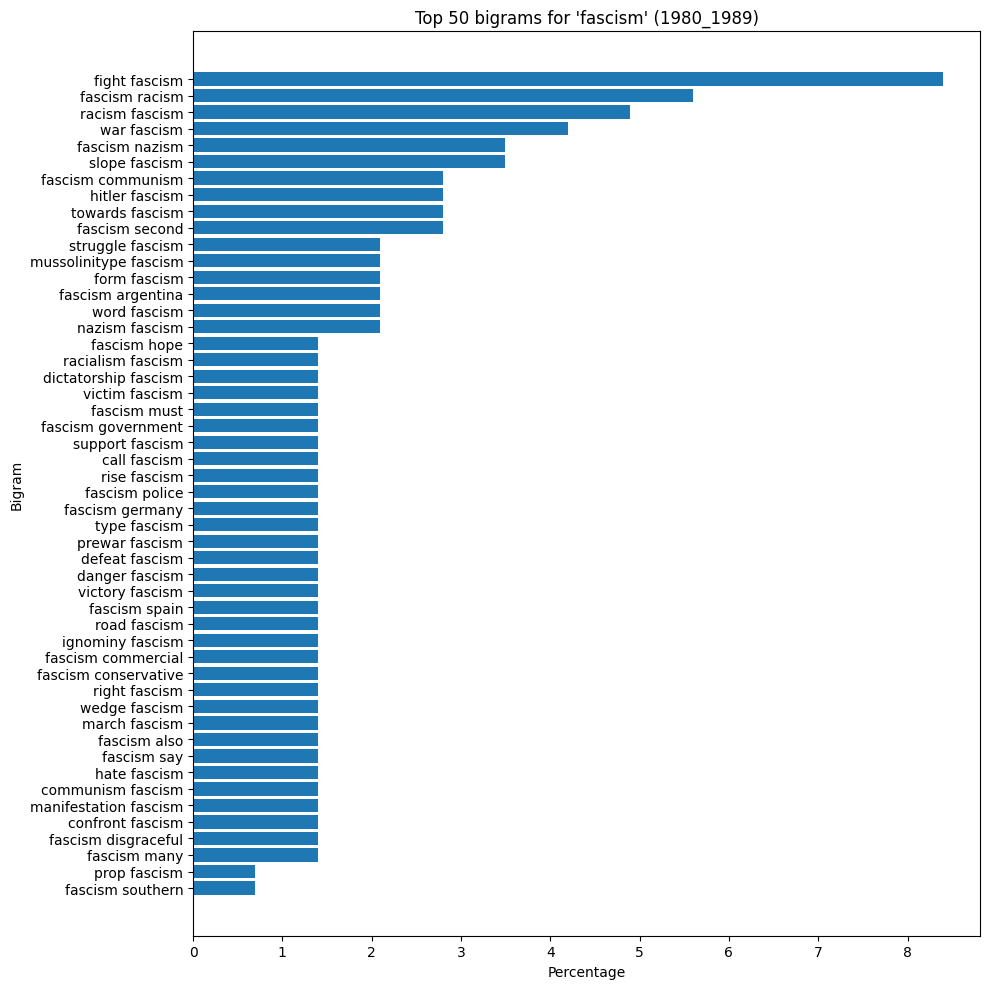

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascism_1990_1999_top50_bigrams_percent.png


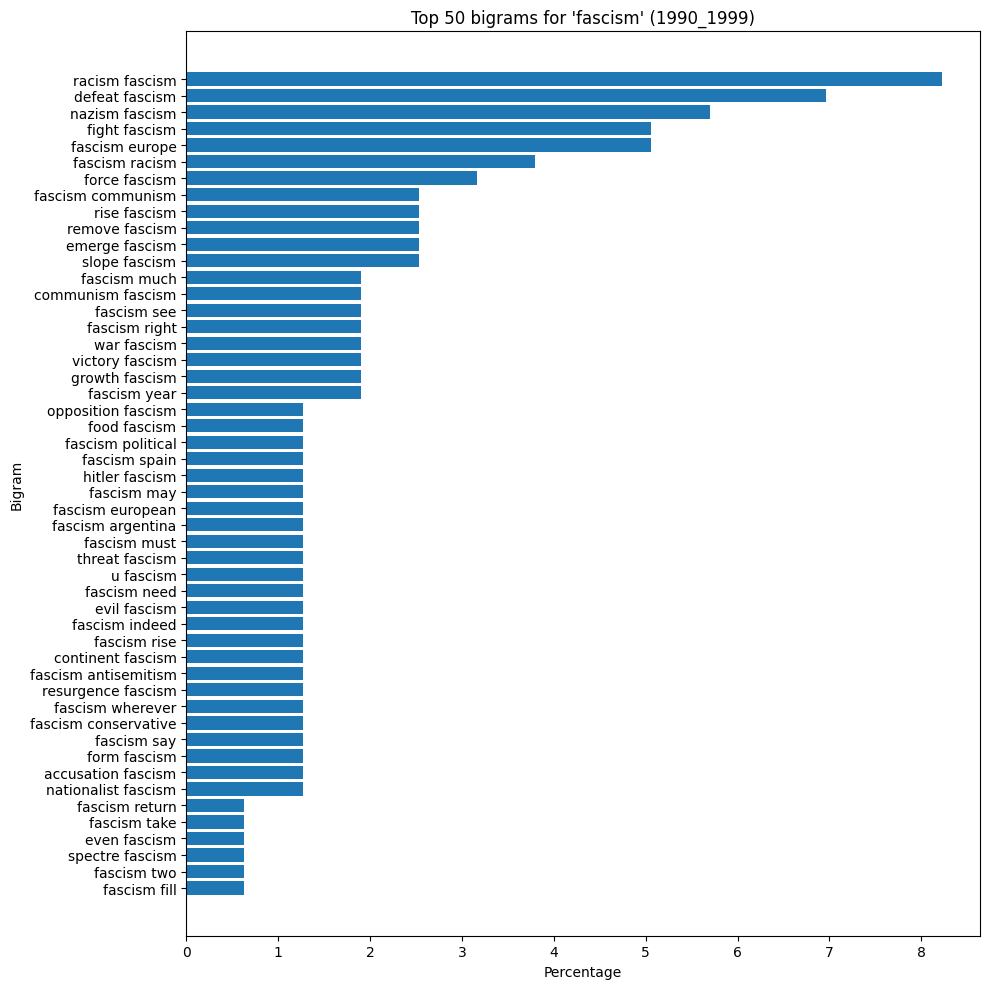

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascism_2000_2009_top50_bigrams_percent.png


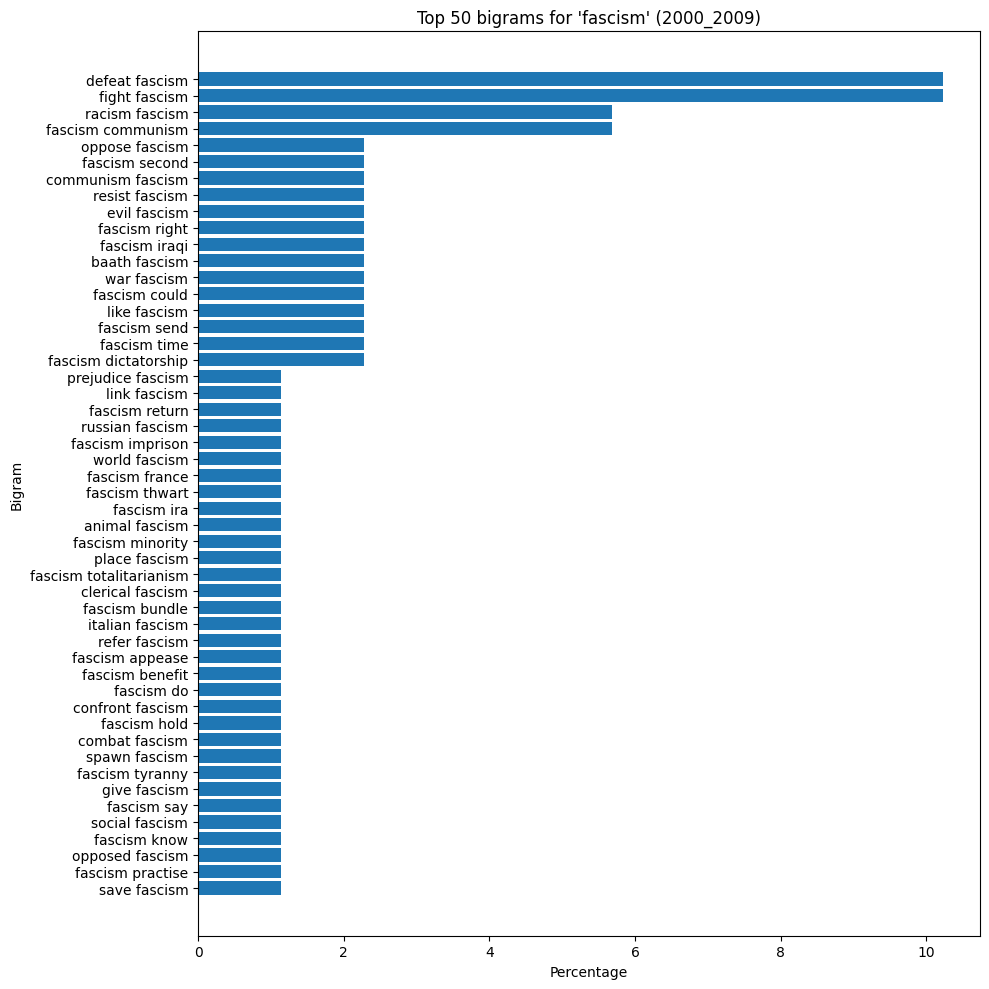

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/fascism_2010_2019_top50_bigrams_percent.png


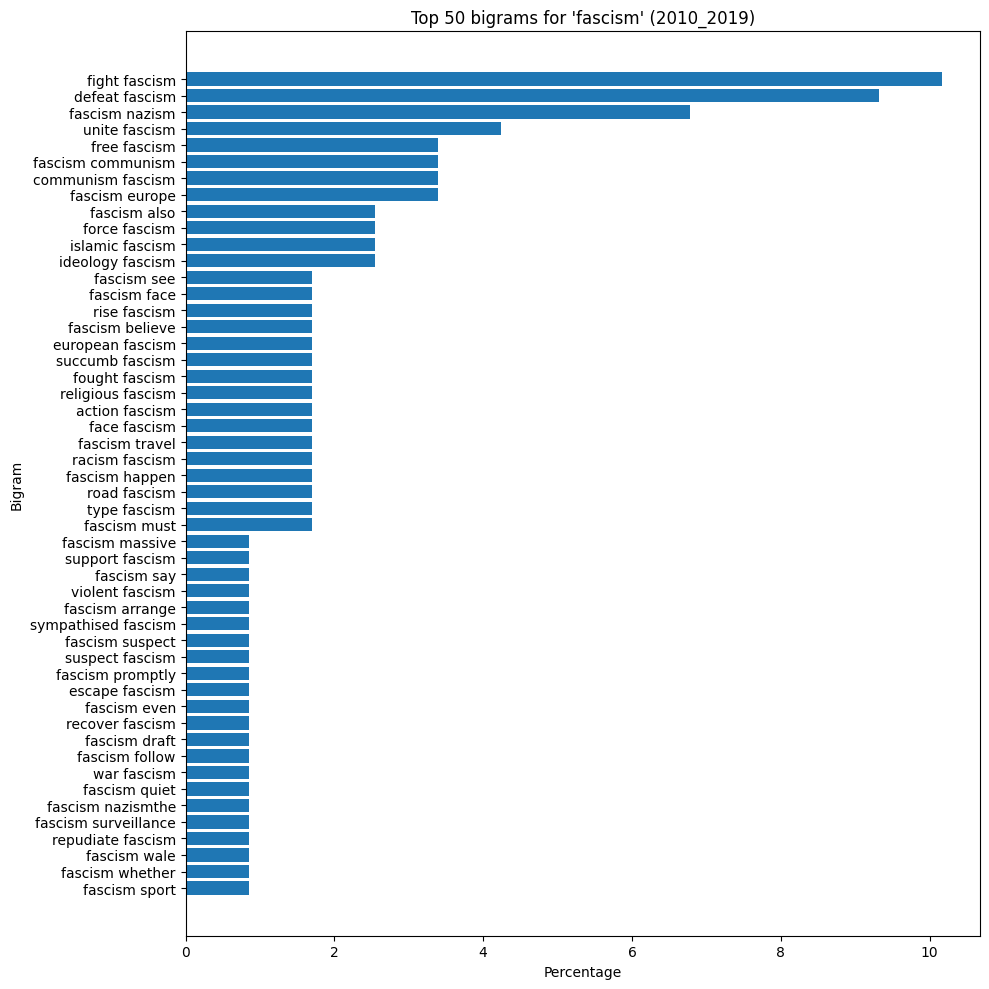

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/crisis_1980_1989_top50_bigrams_percent.png


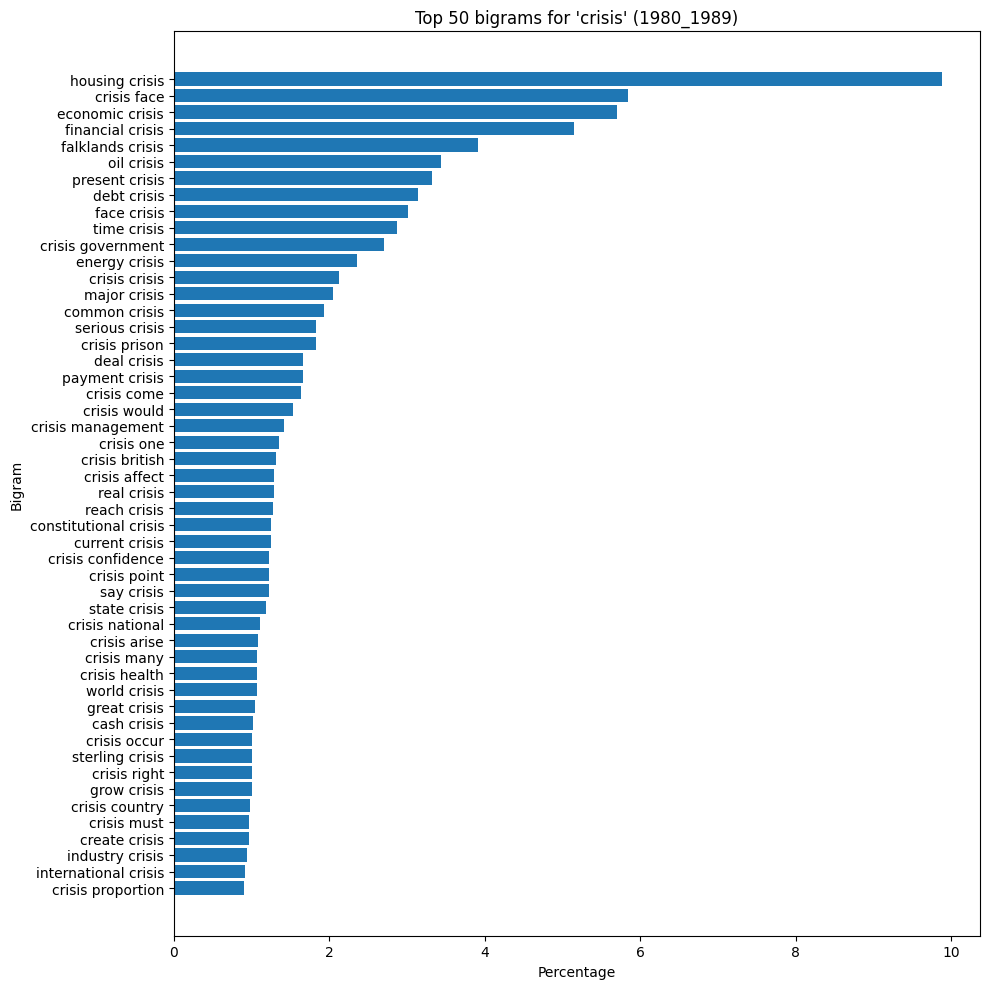

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/crisis_1990_1999_top50_bigrams_percent.png


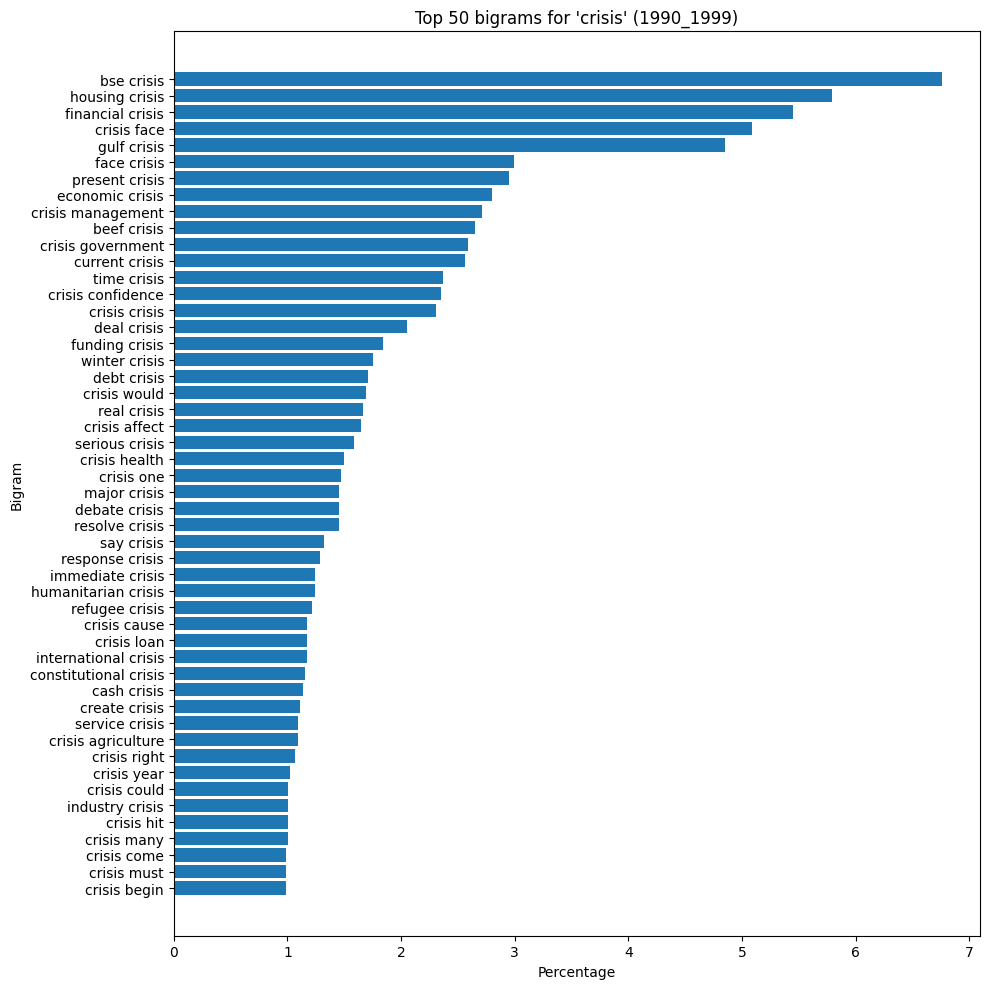

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/crisis_2000_2009_top50_bigrams_percent.png


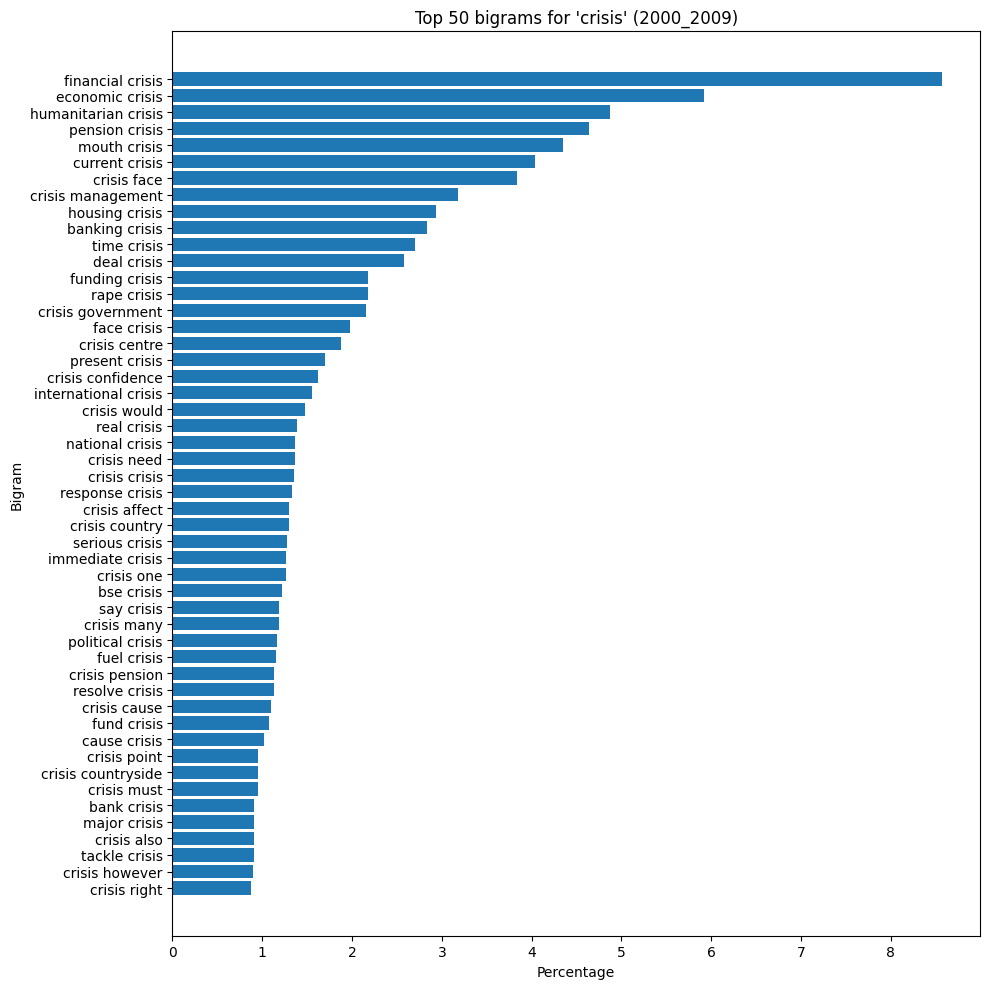

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/crisis_2010_2019_top50_bigrams_percent.png


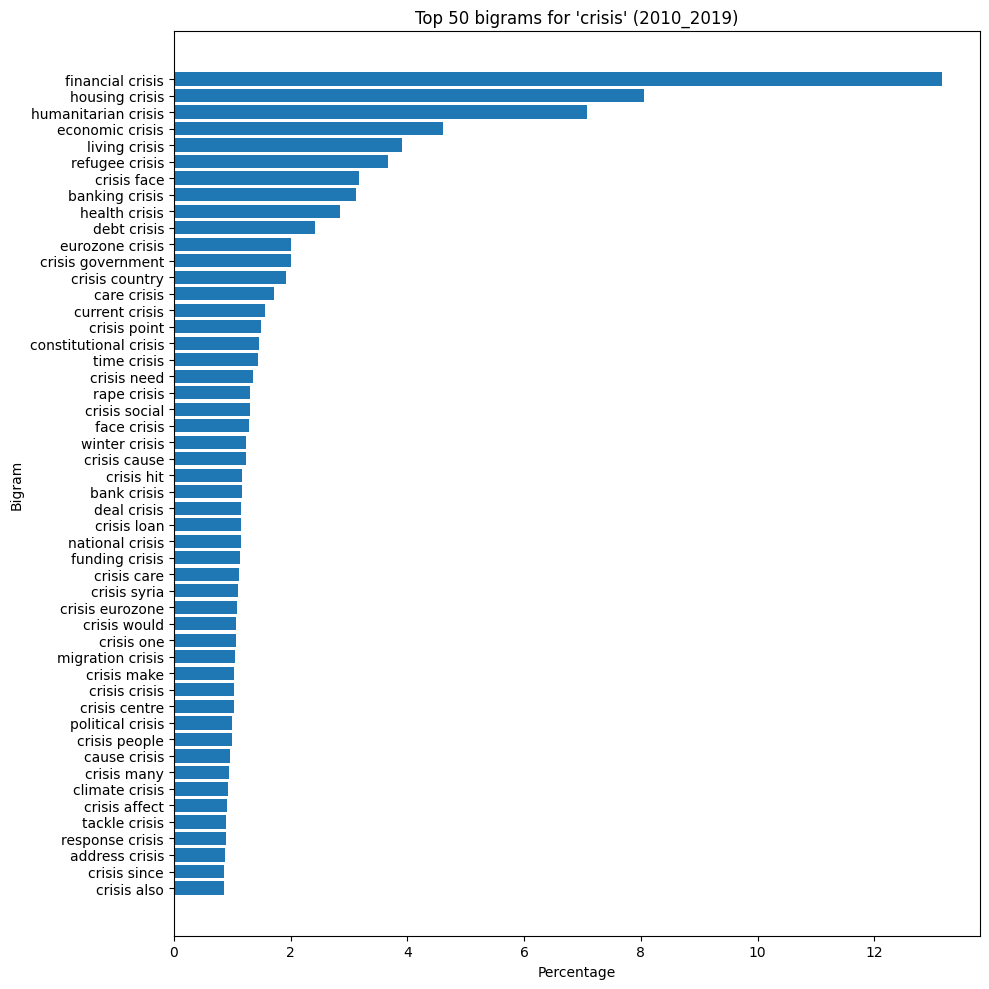

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/critical_1980_1989_top50_bigrams_percent.png


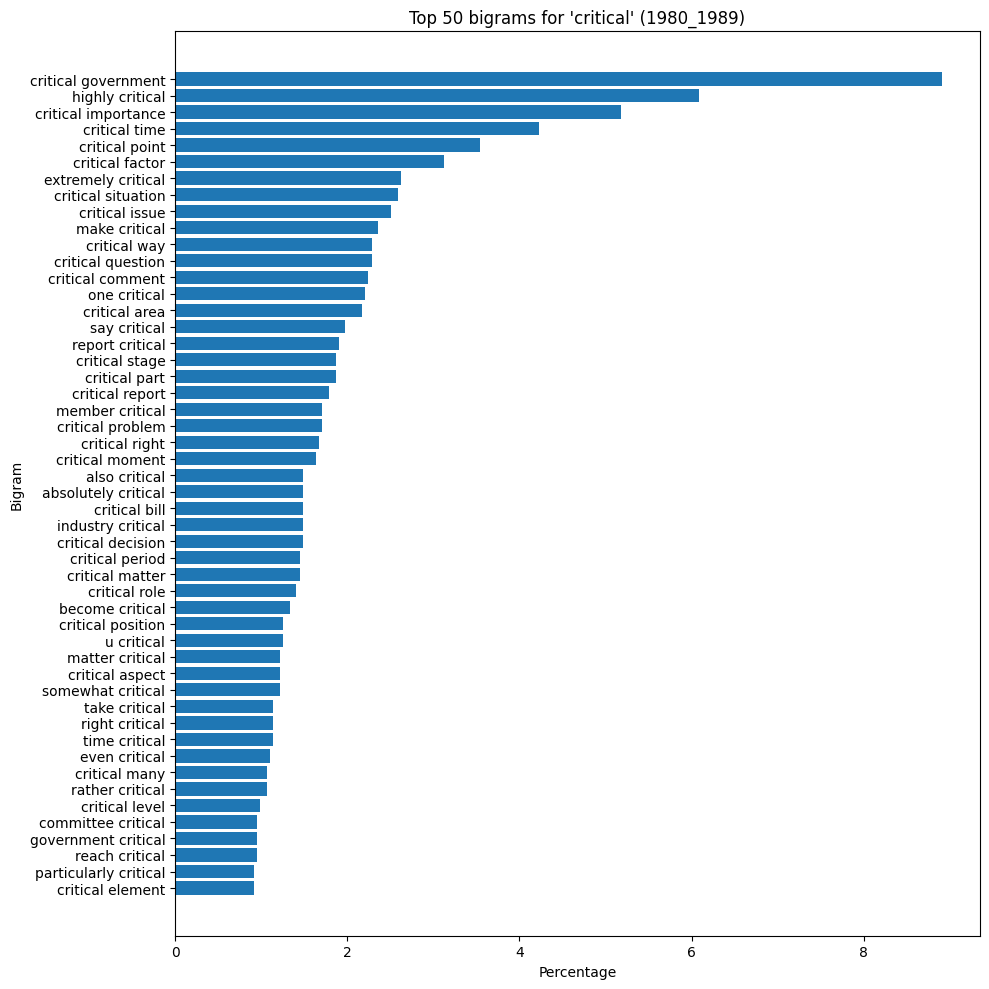

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/critical_1990_1999_top50_bigrams_percent.png


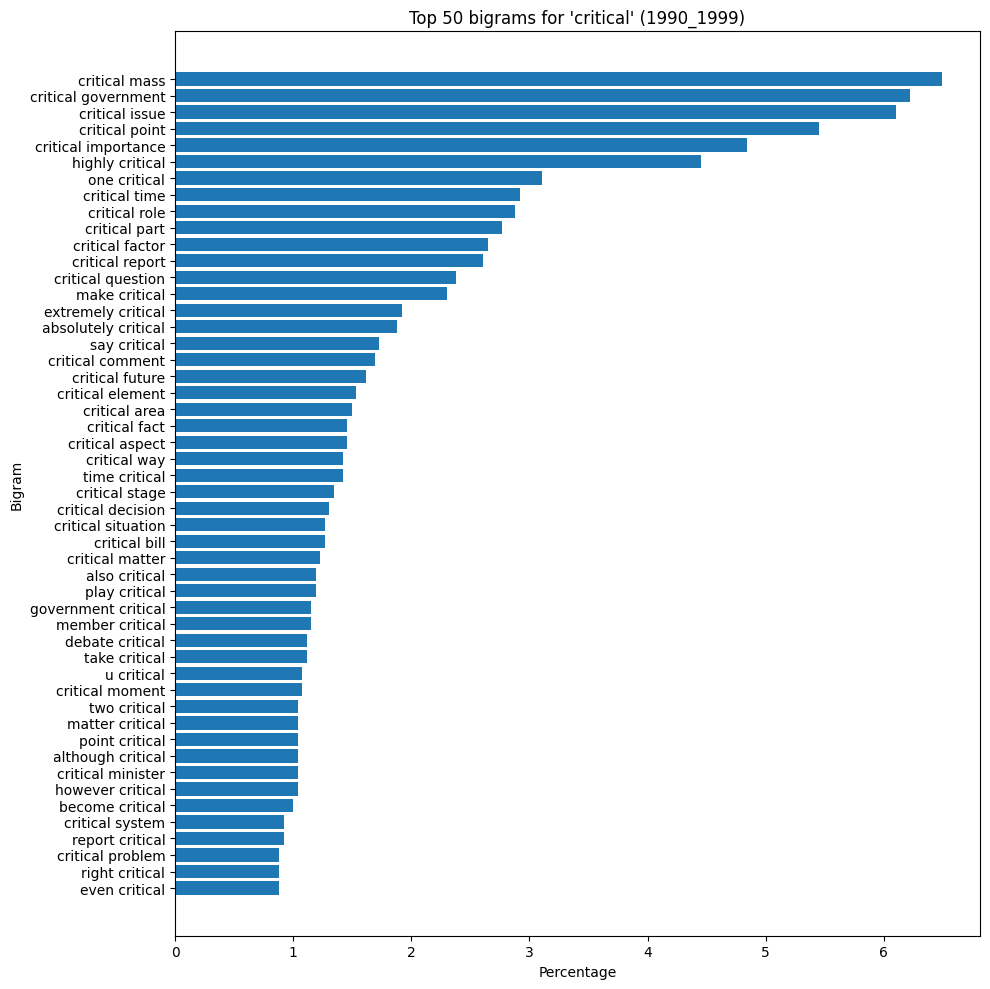

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/critical_2000_2009_top50_bigrams_percent.png


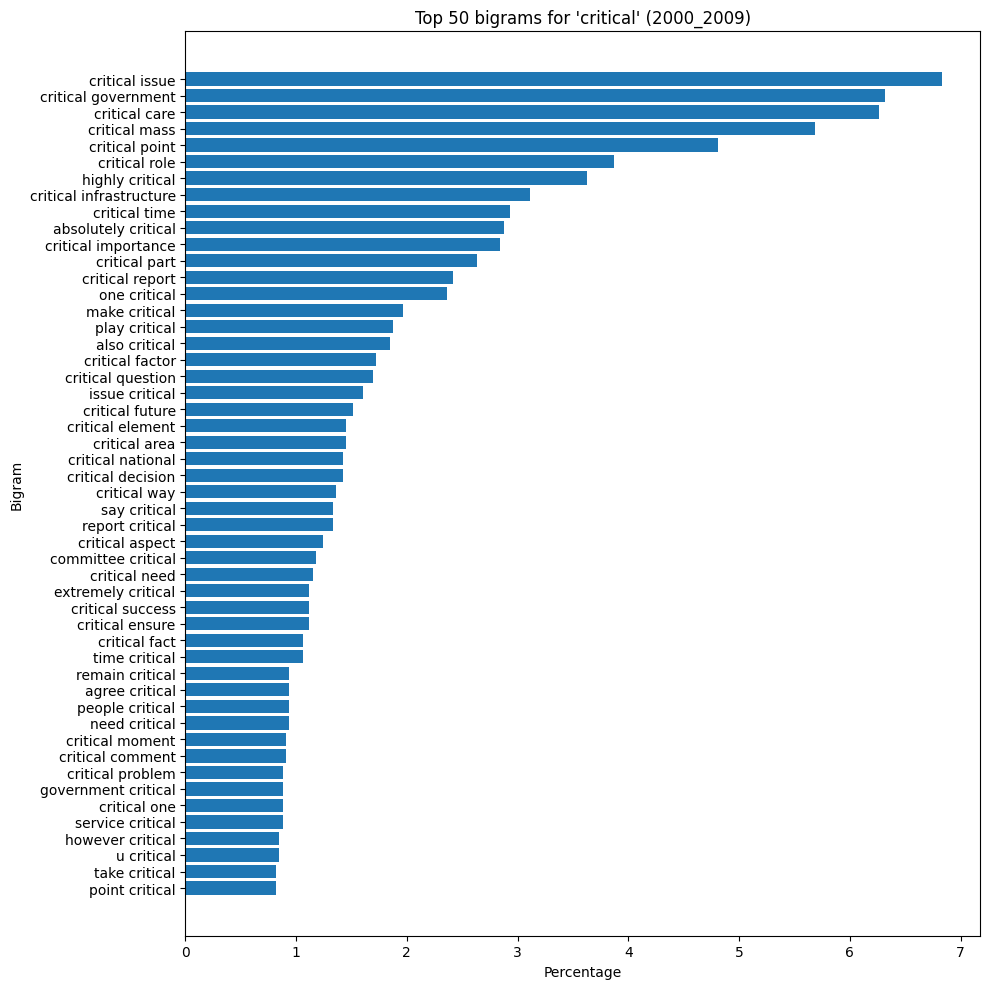

Saved figure: /Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent/critical_2010_2019_top50_bigrams_percent.png


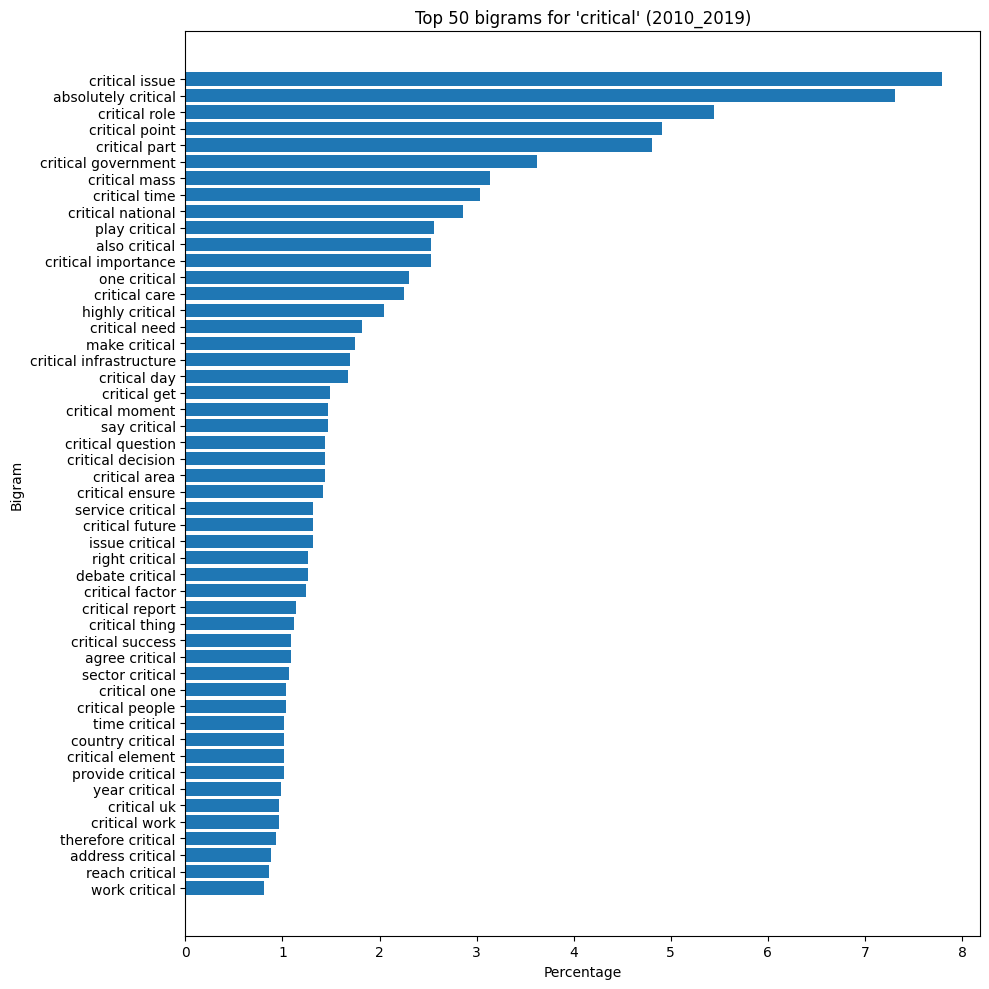

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

top_n = 50

normalized_figure_folder = "/Users/inqfinity/mip/newdecades_bigram_figures_normalized_percent"
os.makedirs(normalized_figure_folder, exist_ok=True)

for target_word in words_to_find:
    for period_name in periods.keys():
        csv_path = f"{output_folder}/{target_word}_{period_name}_top50_bigrams.csv"
        df_plot = pd.read_csv(csv_path)

        if df_plot.empty:
            print(f"No bigrams found for {target_word} | {period_name}")
            continue

        df_plot = df_plot.head(top_n).copy()
        total_count = df_plot["count"].sum()
        df_plot["percent"] = (df_plot["count"] / total_count) * 100
        df_plot = df_plot.sort_values("percent", ascending=True)
        plt.figure(figsize=(10, 10))

        plt.barh(df_plot["bigram"], df_plot["percent"])

        plt.title(f"Top {top_n} bigrams for '{target_word}' ({period_name})")
        plt.xlabel("Percentage")
        plt.ylabel("Bigram")

        plt.tight_layout()

        figure_path = (f"{normalized_figure_folder}/" f"{target_word}_{period_name}_top50_bigrams_percent.png")

        plt.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {figure_path}")

        plt.show()
        plt.close()

## Overlaps? Are they significant?

Again, following EE, I looked at the how far popular bigrams in one decade differed from the prior decade. I also calculated Spearman's Rho value (which also chugs out the p value). The p value can help inform us to what extent this is "based on chance." We got low p-values, which means that our table's data is statistically significant and unlikely to be driven by pure luck or chance! As with the rho value, it can range from -1 to 1, with -1 meaning fully opposed, 0 meaning no (monotonic) correlation, and +1 meaning a fully positive correlation. When read with the # of agreements, the rho value can help us inform if words or trends change. Since we already counted the overlapped terms, the rho value can help tell whether the overlap was statistically significant in any way.

In [7]:
from scipy.stats import spearmanr

comparison_results = []

period_names = list(periods.keys()) #order da periods

for target_word in words_to_find:

    print(f"{target_word.upper()}")

    for i in range(1, len(period_names)): #compare to prev
        previous_period = period_names[i - 1]
        current_period = period_names[i]

        prev_path = (f"{output_folder}/" f"{target_word}_{previous_period}_top50_bigrams.csv")

        curr_path = (f"{output_folder}/" f"{target_word}_{current_period}_top50_bigrams.csv")

        prev_df = pd.read_csv(prev_path)
        curr_df = pd.read_csv(curr_path)

        prev_df["rank_prev"] = range(1, len(prev_df) + 1) #add rank
        curr_df["rank_curr"] = range(1, len(curr_df) + 1)
        overlap = set(prev_df["bigram"]).intersection(set(curr_df["bigram"]))
        recurring_number = len(overlap)
        recurring_percentage = (recurring_number / 50) * 100
        prev_overlap = (prev_df[prev_df["bigram"].isin(overlap)] [["bigram", "rank_prev"]] )
        curr_overlap = (curr_df[curr_df["bigram"].isin(overlap)] [["bigram", "rank_curr"]])

        merged = pd.merge(prev_overlap, curr_overlap, on="bigram")

        if len(merged) >= 2: #spearman
            rho, p_value = spearmanr(merged["rank_prev"], merged["rank_curr"])

        else:
            rho = None
            p_value = None

        comparison_results.append({"target_word": target_word, "decade": current_period, "previous_decade": previous_period, "recurring_bigrams_number": recurring_number, "recurring_bigram_percentage": recurring_percentage, "spearman_rho": rho, "p_value": p_value})

        print(current_period, "& overlap:", recurring_number, "& rho:", rho)

comparison_df = pd.DataFrame(comparison_results)
comparison_df

DEMOCRATIC
1990_1999 & overlap: 37 & rho: 0.7681365576102418
2000_2009 & overlap: 38 & rho: 0.7791880949775687
2010_2019 & overlap: 37 & rho: 0.8041725936462778
DEMOCRACY
1990_1999 & overlap: 32 & rho: 0.6260997067448679
2000_2009 & overlap: 30 & rho: 0.48031145717463847
2010_2019 & overlap: 32 & rho: 0.8211143695014662
UNDEMOCRATIC
1990_1999 & overlap: 30 & rho: 0.5924360400444939
2000_2009 & overlap: 25 & rho: 0.49538461538461537
2010_2019 & overlap: 24 & rho: 0.5539130434782608
FASCIST
1990_1999 & overlap: 23 & rho: 0.44762845849802374
2000_2009 & overlap: 18 & rho: 0.7461300309597524
2010_2019 & overlap: 18 & rho: 0.33952528379772956
FASCISM
1990_1999 & overlap: 18 & rho: 0.38493292053663575
2000_2009 & overlap: 10 & rho: 0.8303030303030302
2010_2019 & overlap: 7 & rho: 0.7857142857142859
CRISIS
1990_1999 & overlap: 31 & rho: 0.7947580645161292
2000_2009 & overlap: 31 & rho: 0.6629032258064517
2010_2019 & overlap: 30 & rho: 0.7134593993325918
CRITICAL
1990_1999 & overlap: 39 & rho:

,target_word,decade,previous_decade,recurring_bigrams_number,recurring_bigram_percentage,spearman_rho,p_value
0,democratic,1990_1999,1980_1989,37,74.0,0.768137,2.861768e-08
1,democratic,2000_2009,1990_1999,38,76.0,0.779188,8.287234e-09
2,democratic,2010_2019,2000_2009,37,74.0,0.804173,2.031906e-09
3,democracy,1990_1999,1980_1989,32,64.0,0.626100,1.266463e-04
4,democracy,2000_2009,1990_1999,30,60.0,0.480311,7.223390e-03
5,democracy,2010_2019,2000_2009,32,64.0,0.821114,8.564583e-09
6,undemocratic,1990_1999,1980_1989,30,60.0,0.592436,5.620122e-04
7,undemocratic,2000_2009,1990_1999,25,50.0,0.495385,1.180247e-02
8,undemocratic,2010_2019,2000_2009,24,48.0,0.553913,4.979948e-03
9,fascist,1990_1999,1980_1989,23,46.0,0.447628,3.220786e-02


Here, I am looking at repeated and unique bigrams relative to the prior decade.

In [8]:
period_names = list(periods.keys())

for target_word in words_to_find:
    print(f"{target_word.upper()}")

    for i in range(1, len(period_names)):
        previous_period = period_names[i - 1]
        current_period = period_names[i]

        prev_df = pd.read_csv(prev_path)
        curr_df = pd.read_csv(curr_path)

        overlap = sorted(set(prev_df["bigram"]).intersection(set(curr_df["bigram"])))

        print(f"\n{previous_period} to {current_period}")
        print(f"Recurring bigrams: {len(overlap)}")

        for bigram in overlap:
            print(bigram)

DEMOCRATIC

1980_1989 to 1990_1999
Recurring bigrams: 34
absolutely critical
agree critical
also critical
critical area
critical care
critical decision
critical element
critical ensure
critical factor
critical future
critical government
critical importance
critical infrastructure
critical issue
critical mass
critical moment
critical national
critical need
critical one
critical part
critical point
critical question
critical report
critical role
critical success
critical time
highly critical
issue critical
make critical
one critical
play critical
say critical
service critical
time critical

1990_1999 to 2000_2009
Recurring bigrams: 34
absolutely critical
agree critical
also critical
critical area
critical care
critical decision
critical element
critical ensure
critical factor
critical future
critical government
critical importance
critical infrastructure
critical issue
critical mass
critical moment
critical national
critical need
critical one
critical part
critical point
critical questio

I then looked at unique bigrams within each category (or words_to_find).

In [9]:
period_names = list(periods.keys())

for target_word in words_to_find:
    print(f"\n{target_word.upper()}")

    for i in range(1, len(period_names)):
        previous_period = period_names[i - 1]
        current_period = period_names[i]

        prev_path = f"{output_folder}/{target_word}_{previous_period}_top50_bigrams.csv"
        curr_path = f"{output_folder}/{target_word}_{current_period}_top50_bigrams.csv"

        prev_df = pd.read_csv(prev_path)
        curr_df = pd.read_csv(curr_path)

        prev_bigrams = set(prev_df["bigram"])
        curr_bigrams = set(curr_df["bigram"])

        unique_current = sorted(curr_bigrams - prev_bigrams)

        print(f"\n{previous_period} to {current_period}")
        print(f"Unique bigrams: {len(unique_current)}")

        for bigram in unique_current:
            print(bigram)


DEMOCRATIC

1980_1989 to 1990_1999
Unique bigrams: 13
democratic accountable
democratic assembly
democratic debate
democratic deficit
democratic legitimacy
democratic mandate
democratic political
democratic reform
democratic voice
make democratic
new democratic
open democratic
peaceful democratic

1990_1999 to 2000_2009
Unique bigrams: 12
democratic change
democratic iraq
democratic parliament
democratic peaceful
democratic politics
democratic representative
democratic scrutiny
democratic value
lack democratic
movement democratic
people democratic
support democratic

2000_2009 to 2010_2019
Unique bigrams: 13
democratic engagement
democratic force
democratic future
democratic oversight
democratic people
democratic vote
great democratic
open democratic
parliament democratic
party democratic
respect democratic
right democratic
undermine democratic

DEMOCRACY

1980_1989 to 1990_1999
Unique bigrams: 18
country democracy
democracy central
democracy eastern
democracy hong
democracy human
dem

## Compiling bigrams with and without KWIC

In the section below, I use KWIC to draw upon a window of 20 words prior and following each bigram occurence. This is (as I have explained in my blog) so that I can label the themes more accurately. Since some bigrams showed up over 2000 times, I think it's fair to claim that they won't all (or even mostly) belong in one category. We need context to clarify those counts! This is something that EE misses out on -- but at the same time, we can't humanly go through tens of thousands of entries.

(Enter LLMs)
I hope this helps clear up some ambiguity in whether "social democratic" refers to, I don't know, a party, or a constitutional issue, or a procedure. The code below helps extract a window of words from our lemmatized corpus to help prepar a `.csv` file that will help us later when we want to label each bigram count indiviually _given_ the context! Of course, lemmatized texts are less accurate than unlemmatized ones, but this is probably the best that I can do with my humble Macbook Air.

In [10]:
from collections import defaultdict

bigram_folder = "/Users/inqfinity/mip/newdecades_bigram_outputs"
kwic_output_folder = "/Users/inqfinity/mip/newdecades_kwic_outputs"

os.makedirs(kwic_output_folder, exist_ok=True)

window = 20  #i'm doing a window of p/m 20 words around the bigram in question

top_bigram_files = glob.glob(f"{bigram_folder}/*_top50_bigrams.csv")

top_bigrams_by_target_period = defaultdict(set)

for path in top_bigram_files:
    df_big = pd.read_csv(path)

    for _, row in df_big.iterrows():
        target = row["target_word"]
        period = row["period"]
        bigram = row["bigram"]

        top_bigrams_by_target_period[(target, period)].add(bigram)

print("Loaded top bigrams from saved files.")
print(f"Number of target-period groups: {len(top_bigrams_by_target_period)}")

Loaded top bigrams from saved files.
Number of target-period groups: 28


In [11]:
for target_word in words_to_find: #here we start extracting kwic left and right of the bigrams

    for period_name, (start_year, end_year) in periods.items():

        selected_bigrams = top_bigrams_by_target_period.get((target_word, period_name), set())

        if not selected_bigrams:
            print(f"No selected bigrams found for {target_word} in {period_name}")
            continue

        print(f"\nExtracting KWIC: {target_word} in {period_name}")
        print(f"Number of selected bigrams: {len(selected_bigrams)}")

        kwic_rows = []

        for file in input_files:
            year = int(file.split("/")[-1][:4])
            if not (start_year <= year <= end_year):
                continue

            df = pd.read_csv(file, low_memory=False)
            df = df[df["speech_class"] == "Speech"]

            for row_index, row in df.iterrows():
                if pd.isna(row["speech_lemmas_list"]):
                    continue
                
                tokens = ast.literal_eval(row["speech_lemmas_list"])

                for i in range(len(tokens) - 1):

                    word1 = tokens[i]
                    word2 = tokens[i + 1]
                    bigram = f"{word1} {word2}"

                    if bigram in selected_bigrams:
                        left_context = tokens[max(0, i - window):i]
                        match = tokens[i:i + 2]
                        right_context = tokens[i + 2:i + 2 + window]

                        kwic_rows.append({"target_word": target_word, "period": period_name, "year": year, "bigram": bigram, "party": row.get("party", ""), "speaker": row.get("speaker", ""), "major_heading": row.get("major_heading", ""), "speech_id": row.get("speech_id", row_index), "left_context": " ".join(left_context), "match": " ".join(match), "right_context": " ".join(right_context), "category_code": ""})

        kwic_df = pd.DataFrame(kwic_rows)

        output_path = (f"{kwic_output_folder}/" f"{target_word}_{period_name}_kwic_top50_bigrams.csv")

        kwic_df.to_csv(output_path, index=False)

        print(f"Saved: {output_path}")
        print(f"Rows: {len(kwic_df)}")
        print(kwic_df.head())


Extracting KWIC: democratic in 1980_1989
Number of selected bigrams: 50
Saved: /Users/inqfinity/mip/newdecades_kwic_outputs/democratic_1980_1989_kwic_top50_bigrams.csv
Rows: 9643
  target_word     period  year                bigram         party speaker  \
0  democratic  1980_1989  1979      democratic right  Conservative           
1  democratic  1980_1989  1979    democratic society  Conservative           
2  democratic  1980_1989  1979      democratic right        Labour           
3  democratic  1980_1989  1979      democratic party  Conservative           
4  democratic  1980_1989  1979  democratic socialist        Labour           

           major_heading  speech_id  \
0    ELECTION OF SPEAKER          6   
1  DEBATE ON THE ADDRESS        775   
2  DEBATE ON THE ADDRESS        778   
3  DEBATE ON THE ADDRESS        795   
4  DEBATE ON THE ADDRESS        804   

                                        left_context                 match  \
0  par rather one boys one mr speaker 

In hindsight, that took a long time to run and that is a task for later. Let's just compile the unique bigrams alone for now, so that I can realistically label them.

In [17]:
bigram_folder = "/Users/inqfinity/mip/newdecades_bigram_outputs"

dictionary_output_path = "/Users/inqfinity/mip/all_unique_bigrams_for_coding.csv"

all_dfs = []

bigram_files = glob.glob(f"{bigram_folder}/*_top50_bigrams.csv")

for path in bigram_files:
    df = pd.read_csv(path)
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

summary_df = (combined_df.groupby(["target_word", "bigram"]).agg(total_count=("count", "sum"), periods_present=("period", "nunique"), periods_list=("period", lambda x: ", ".join(sorted(x.unique())))).reset_index())
summary_df = summary_df.sort_values(["target_word", "periods_present", "total_count"], ascending=[True, False, False])
summary_df["category_code"] = ""
summary_df.to_csv(dictionary_output_path, index=False)

print(dictionary_output_path)

#print(summary_df.head(50))

/Users/inqfinity/mip/all_unique_bigrams_for_coding.csv
